<a href="https://colab.research.google.com/github/joanby/matematicas-ml/blob/master/2_linear_algebra_ii.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Álgebra Lineal II: Operaciones Matriciales

Este tema, *Álgebra lineal II: operaciones con matrices*, se basa en los fundamentos del álgebra lineal. Es esencial porque estas manipulaciones de nivel intermedio de tensores se encuentran en el corazón de la mayoría de los enfoques de aprendizaje automático y son especialmente predominantes en el aprendizaje profundo.

A través de la exposición mesurada de la teoría emparejada con ejemplos interactivos, desarrollará una comprensión de cómo se utiliza el álgebra lineal para resolver valores desconocidos en espacios de alta dimensión, así como para reducir la dimensionalidad de los espacios complejos. El contenido cubierto en este tema es en sí mismo fundamental para varios otros temas de la serie *Fundamentos del Aprendizaje Automático*, especialmente *Probabilidad y Teoría de la Información* y *Optimización*.

Over the course of studying this topic, you'll:

* Develop a geometric intuition of what’s going on beneath the hood of machine learning algorithms, including those used for deep learning.
* Be able to more intimately grasp the details of machine learning papers as well as all of the other subjects that underlie ML, including calculus, statistics, and optimization algorithms.
* Reduce the dimensionalty of complex spaces down to their most informative elements with techniques such as eigendecomposition, singular value decomposition, and principal component analysis.

**Tenga en cuenta que este cuaderno Jupyter no está diseñado para funcionar por sí solo. Es el código que acompaña a una clase o a los vídeos de la serie [Machine Learning Foundations](https://github.com/jonkrohn/ML-foundations) de Jon Krohn, que ofrecen detalles sobre lo siguiente:**

*Segmento 1: Revisión de álgebra lineal introductoria*

* Aplicaciones modernas de álgebra lineal
* Tensores, vectores y normas
* Multiplicación de matrices
* Inversión de matrices
* Matrices de identidad, diagonales y ortogonales

*Segmento 2: Eigendecomposición

* Transformación Afín mediante Aplicación Matricial
* Vectores y valores propios
* Determinantes matriciales
* Descomposición de matrices
* Aplicaciones de la Eigendecomposición

*Segmento 3: Operaciones Matriciales para el Aprendizaje Automático

* Descomposición de Valores Singulares (SVD)
* La pseudoinversa de Moore-Penrose
* El operador Trace
* Análisis de Componentes Principales (ACP): Un algoritmo sencillo de aprendizaje automático
* Recursos para profundizar en el álgebra lineal

## Resumen: Lo Más Importante de Este Notebook

Una chuleta rápida con lo esencial, para tener una vista de conjunto antes de empezar (o repasar después sin releer todo el notebook).

### Transformaciones lineales y vectores propios

* Aplicar una matriz $A$ a un vector ($Av$) es una **transformación lineal**: puede rotarlo, reescalarlo y/o reflejarlo.
* **Vector propio** $v$: una dirección especial que $A$ **no rota**, solo reescala. **Valor propio** $\lambda$: el factor por el que lo escala. $$Av=\lambda v$$
* `lambdas, V = np.linalg.eig(A)` — ¡cuidado!: $V$ (mayúscula) son los **vectores** propios, $\lambda$ (minúscula) son los **valores** propios.

### Determinante

* $\det(A)$: un número que mide cuánto escala $A$ el área (2D) o el volumen (nD). Para $2\times2$: $\det(A)=ad-bc$.
* $\det(A)=0 \Leftrightarrow$ $A$ es **singular** (no tiene inversa).
* $\det(A) = \lambda_1 \cdot \lambda_2 \cdots \lambda_n$ — el producto de todos los valores propios.

### Descomposición propia (eigendecomposition)

* $A = V\Lambda V^{-1}$ ($\Lambda$ = valores propios en una diagonal). Si $A$ es **simétrica**, se puede escribir como $A=Q\Lambda Q^T$ (más barato, porque $Q$ sale ortogonal).
* **¿Para qué sirve?** No para «reconstruir $A$» (eso solo confirma que está bien hecha) — sirve porque $\Lambda$ es diagonal y muy barata de operar: potencias de una matriz ($A^n=V\Lambda^nV^{-1}$), analizar estabilidad de un sistema, y es la base matemática de **PCA**.

### SVD y Pseudoinversa

* **SVD** ($A=UDV^T$): como la descomposición propia, pero funciona con **cualquier matriz**, incluso no cuadrada.
* **Pseudoinversa de Moore-Penrose** ($A^+=VD^+U^T$): el equivalente a «la inversa» para matrices que no tienen inversa de verdad (no cuadradas o singulares).
* **Traza** $\text{Tr}(A)=\sum_i A_{i,i}$: la suma de la diagonal.

### PCA y aplicaciones reales

* **PCA**: aplica esta misma descomposición (propia o SVD) a la matriz de covarianza de un dataset para reducir su dimensionalidad — los vectores propios son las direcciones de máxima varianza. Ejemplo real del notebook: en Iris, 2 componentes principales (de 4 *features* originales) capturan ≈97.8% de toda la varianza.
* El mismo patrón ($Av=\lambda v$) aparece en sitios muy distintos: **Eigenfaces** (reconocimiento facial), **PageRank** (buscadores), cadenas de Markov, análisis de vibraciones e ingeniería estructural, y compresión de imágenes.

## Segmento 1: Repaso de Introducción al álgebra lineal

Antes de avanzar hacia la descomposición en valores y vectores propios, repasamos rápidamente —ya usando tanto NumPy como PyTorch en paralelo— los conceptos fundamentales vistos en *Introducción al Álgebra Lineal*: transposición, normas, matrices y su multiplicación, e inversión de matrices.

In [129]:
import numpy as np
import torch

### Transposición de Vectores

Recordatorio: **transponer** un vector cambia un vector fila por uno columna (o viceversa), denotado $v^T$. Como vimos en el notebook anterior, esto solo tiene un efecto visible cuando el vector está representado con 2 dimensiones explícitas (una matriz de 1 fila o 1 columna); un array 1-D «plano» no cambia al transponerlo.

In [130]:
x = np.array([25, 2, 5])
x

array([25,  2,  5])

In [131]:
x.shape

(3,)

In [132]:
x = np.array([[25, 2, 5]])
x

array([[25,  2,  5]])

In [133]:
x.shape

(1, 3)

In [134]:
x.T

array([[25],
       [ 2],
       [ 5]])

In [135]:
x.T.shape

(3, 1)

In [136]:
x_p = torch.tensor([25, 2, 5])
x_p

tensor([25,  2,  5])

In [137]:
x_p.T

tensor([25,  2,  5])

In [138]:
x_p = torch.tensor([[25, 2, 5]])
x_p

tensor([[25,  2,  5]])

In [139]:
x_p.T

tensor([[25],
        [ 2],
        [ 5]])

In [140]:
x_p = torch.tensor([25, 2, 5])
x_p.view(3, 1) # "view" porque estamos cambiando la salida pero no la forma en que x se almacena en la memoria

tensor([[25],
        [ 2],
        [ 5]])

`view()` es el equivalente en PyTorch a `reshape()`: reorganiza la forma de un tensor sin copiar sus datos en memoria (a diferencia de `.T`, que es específicamente la transposición).

**Volver a las slides aquí.**

## Norma $L^2$

Recordatorio: la norma $L^2$ (euclídea) de un vector es $\|x\|_2=\sqrt{\sum_i x_i^2}$, la distancia en línea recta desde el origen hasta el punto que representa el vector.

In [141]:
x

array([[25,  2,  5]])

In [142]:
(25**2 + 2**2 + 5**2)**(1/2)

25.573423705088842

In [143]:
np.linalg.norm(x)

np.float64(25.573423705088842)

In [144]:
# la siguiente línea de código fallará porque torch.norm() requiere que la entrada sea float y no integer


In [145]:
torch.norm(torch.tensor([25, 2, 5]))

RuntimeError: linalg.vector_norm: Expected a floating point or complex tensor as input. Got Long

In [ ]:
torch.norm(torch.tensor([25, 2, 5.]))

tensor(25.5734)

**Volver a las slides aquí.**

### Matrices

Recordatorio: una **matriz** es un array bidimensional de números (filas × columnas), normalmente denotada con una letra mayúscula.

In [ ]:
X = np.array([[25, 2], [5, 26], [3, 7]])
X

array([[25,  2],
       [ 5, 26],
       [ 3,  7]])

In [ ]:
X.shape

(3, 2)

In [ ]:
X_p = torch.tensor([[25, 2], [5, 26], [3, 7]])
X_p

tensor([[25,  2],
        [ 5, 26],
        [ 3,  7]])

In [ ]:
X_p.shape

torch.Size([3, 2])

### Transposición de Matrices

Al igual que con los vectores, transponer una matriz $X$ (denotado $X^T$) intercambia sus filas por columnas: una matriz $m\times n$ se convierte en una $n\times m$, donde el elemento $(i,j)$ pasa a la posición $(j,i)$.

In [ ]:
X

array([[25,  2],
       [ 5, 26],
       [ 3,  7]])

In [ ]:
X.T

array([[25,  5,  3],
       [ 2, 26,  7]])

In [ ]:
X_p.T

tensor([[25,  5,  3],
        [ 2, 26,  7]])

**volver a las slides aquí.**

### Multiplicación de Matrices

«Multiplicar matrices» puede referirse en realidad a varias operaciones distintas, que vamos a repasar una por una:

* **Escalar × matriz**: multiplicar cada elemento por un número.
* **Producto de Hadamard** (elemento a elemento, $A\odot B$): requiere que ambos tensores tengan la misma forma.
* **Matriz × vector**: cada fila de la matriz se combina (producto punto) con el vector.
* **Matriz × matriz**: la auténtica «multiplicación de matrices», donde $(m\times n)(n\times p) = (m\times p)$.

Se aplican escalares a cada elemento de la matriz:

In [ ]:
X*3

array([[75,  6],
       [15, 78],
       [ 9, 21]])

In [ ]:
X*3+3

array([[78,  9],
       [18, 81],
       [12, 24]])

In [ ]:
X_p*3

tensor([[75,  6],
        [15, 78],
        [ 9, 21]])

In [ ]:
X_p*3+3

tensor([[78,  9],
        [18, 81],
        [12, 24]])

Usar el operador de multiplicación en dos tensores del mismo tamaño en PyTorch (o Numpy o TensorFlow) aplica operaciones de elemento a elemento. Este es el **producto Hadamard** (denotado por el operador $\odot$, por ejemplo, $A \odot B$, con $(A \odot B)_{i,j} = A_{i,j}\cdot B_{i,j}$) *no* **multiplicación de matrices**:

In [ ]:
A = np.array([[3, 4], [5, 6], [7, 8]])
A

array([[3, 4],
       [5, 6],
       [7, 8]])

In [ ]:
X

array([[25,  2],
       [ 5, 26],
       [ 3,  7]])

In [ ]:
X * A

array([[ 75,   8],
       [ 25, 156],
       [ 21,  56]])

In [ ]:
A_p = torch.tensor([[3, 4], [5, 6], [7, 8]])
A_p

tensor([[3, 4],
        [5, 6],
        [7, 8]])

In [ ]:
X_p * A_p

tensor([[ 75,   8],
        [ 25, 156],
        [ 21,  56]])

**Producto de Matriz por Vector**: al multiplicar una matriz $A$ (de $m\times n$) por un vector $b$ (de $n$ elementos), cada fila de $A$ se combina con $b$ mediante un producto punto, dando como resultado un nuevo vector de $m$ elementos:

In [ ]:
b = np.array([1, 2])
b

array([1, 2])

In [ ]:
np.dot(A, b) # aunque técnicamente el producto punto es entre 2 vectores

array([11, 17, 23])

In [ ]:
b_p = torch.tensor([1, 2])
b_p

tensor([1, 2])

In [ ]:
torch.matmul(A_p, b_p)

tensor([11, 17, 23])

**Multiplicación de dos matrices**: para multiplicar $A$ ($m\times n$) por $B$ ($n\times p$), el número de columnas de $A$ debe coincidir con el número de filas de $B$; el resultado es una matriz $m\times p$. A diferencia del producto de Hadamard, aquí sí importa el orden: en general $AB \neq BA$ (no es conmutativa):

In [ ]:
B = np.array([[1, 9], [2, 0]])
B

array([[1, 9],
       [2, 0]])

In [ ]:
np.dot(A, B) # la primera columna es lo mismo que Xb

array([[11, 27],
       [17, 45],
       [23, 63]])

In [ ]:
B_p = torch.tensor([[1, 9], [2, 0]])
B_p

tensor([[1, 9],
        [2, 0]])

In [ ]:
torch.matmul(A_p, B_p)

tensor([[11, 27],
        [17, 45],
        [23, 63]])

### Inversa de una matriz

Recordatorio: la inversa de $X$, denotada $X^{-1}$, es la matriz que cumple $XX^{-1}=X^{-1}X=I$. Nos permite «despejar» $w$ en un sistema $Xw=y$ sin más que multiplicar ambos lados por $X^{-1}$: $w = X^{-1}y$.

In [ ]:
X = np.array([[4, 2], [-5, -3]])
X

array([[ 4,  2],
       [-5, -3]])

In [ ]:
Xinv = np.linalg.inv(X)
Xinv

array([[ 1.5,  1. ],
       [-2.5, -2. ]])

In [ ]:
i=np.dot(X, Xinv)
i

array([[ 1.0000000e+00, -4.4408921e-16],
       [ 4.4408921e-16,  1.0000000e+00]])

In [ ]:
y = np.array([4, -7])
y

array([ 4, -7])

In [ ]:
w = np.dot(Xinv, y)
w

array([-1.,  4.])

Demostrar que $y = Xw$:

In [ ]:
np.dot(X, w)

array([ 4., -7.])

In [ ]:
X_p = torch.tensor([[4, 2], [-5, -3.]]) # notar que torch.inverse() requiere floats
X_p

tensor([[ 4.,  2.],
        [-5., -3.]])

In [ ]:
Xinv_p = torch.inverse(X_p)
Xinv_p

tensor([[ 1.5000,  1.0000],
        [-2.5000, -2.0000]])

In [ ]:
y_p = torch.tensor([4, -7.])
y_p

tensor([ 4., -7.])

In [ ]:
w_p = torch.matmul(Xinv_p, y_p)
w_p

tensor([-1.0000,  4.0000])

In [ ]:
torch.matmul(X_p, w_p)

tensor([ 4.0000, -7.0000])

**Volver a las slides aquí.**

## Segmento 2: Descomposición en Valores y Vectores Propios

En este segmento damos un paso más: veremos cómo interpretar geométricamente la multiplicación matriz-vector como una **transformación lineal**, qué son los **valores y vectores propios** (la dirección e intensidad «naturales» de esa transformación), qué mide el **determinante** de una matriz, y cómo combinarlo todo en la **descomposición propia** (*eigendecomposition*) de una matriz.

### Transformación Afín mediante Aplicación Matricial

Aplicar una matriz $A$ a un vector $v$ (es decir, calcular $Av$) es la operación central de este segmento: geométricamente, **transforma** el vector — puede rotarlo, reescalarlo, reflejarlo, o una combinación de todo eso. A esto se le llama una **transformación lineal** (o, en su versión más general con desplazamientos, *afín*). Vamos a verlo con ejemplos concretos antes de preguntarnos: ¿hay direcciones especiales que $A$ no rota, sino que solo reescala? Esa pregunta es la puerta de entrada a los vectores propios.

Supongamos que tenemos un vector $v$:

In [ ]:
v = np.array([3, 1])
v

array([3, 1])

Vamos a representar $v$ usando mi función `plot_vectors()` (que está basada en la función `plotVectors()` de Hadrien Jean de [este cuaderno](https://github.com/hadrienj/deepLearningBook-Notes/blob/master/2.7%20Eigendecomposition/2.7%20Eigendecomposition.ipynb), bajo [licencia MIT](https://github.com/hadrienj/deepLearningBook-Notes/blob/master/LICENSE)).

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
def plot_vectors(vectors, colors):
    """
    Plot one or more vectors in a 2D plane, specifying a color for each.

    Arguments
    ---------
    vectors: list of lists or of arrays
        Coordinates of the vectors to plot. For example, [[1, 3], [2, 2]]
        contains two vectors to plot, [1, 3] and [2, 2].
    colors: list
        Colors of the vectors. For instance: ['red', 'blue'] will display the
        first vector in red and the second in blue.

    Example
    -------
    plot_vectors([[1, 3], [2, 2]], ['red', 'blue'])
    plt.xlim(-1, 4)
    plt.ylim(-1, 4)
    """
    plt.figure()
    plt.axvline(x=0, color='lightgray')
    plt.axhline(y=0, color='lightgray')

    for i in range(len(vectors)):
        x = np.concatenate([[0,0],vectors[i]])
        plt.quiver([x[0]], [x[1]], [x[2]], [x[3]],
                   angles='xy', scale_units='xy', scale=1, color=colors[i],)

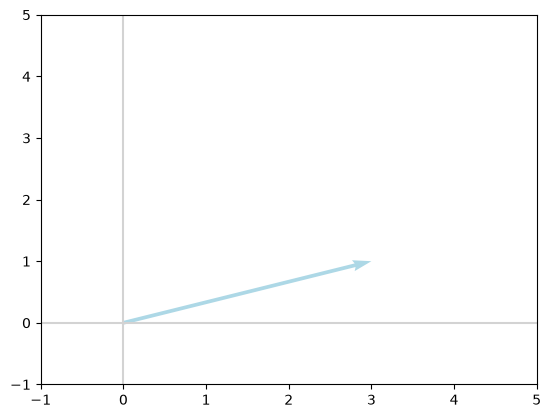

In [ ]:
plot_vectors([v], ['lightblue'])
plt.xlim(-1, 5)
_ = plt.ylim(-1, 5)

Aplicar una matriz a un vector (es decir, realizar una multiplicación matriz-vector) puede transformar linealmente el vector, por ejemplo, rotarlo o reescalarlo.

La matriz identidad, introducida anteriormente, es la excepción que confirma la regla: La aplicación de una matriz identidad no transforma el vector:

In [ ]:
I = np.array([[1, 0], [0, 1]])
I

array([[1, 0],
       [0, 1]])

In [ ]:
Iv = np.dot(I, v)
Iv

array([3, 1])

In [ ]:
v == Iv

array([ True,  True])

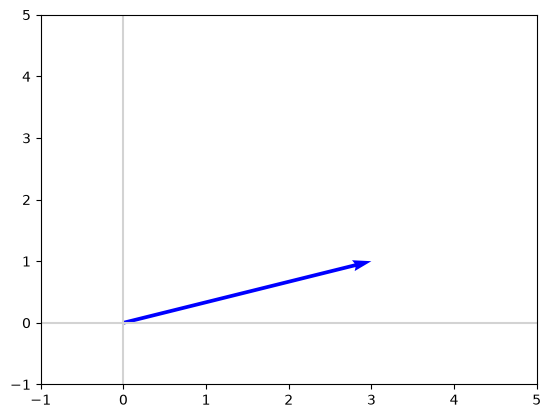

In [ ]:
plot_vectors([Iv], ['blue'])
plt.xlim(-1, 5)
_ = plt.ylim(-1, 5)

Por el contrario, consideremos esta matriz (llamémosla $E$) que voltea los vectores sobre el eje $x$:

In [ ]:
E = np.array([[1, 0], [0, -1]])
E

array([[ 1,  0],
       [ 0, -1]])

In [ ]:
Ev = np.dot(E, v)
Ev

array([ 3, -1])

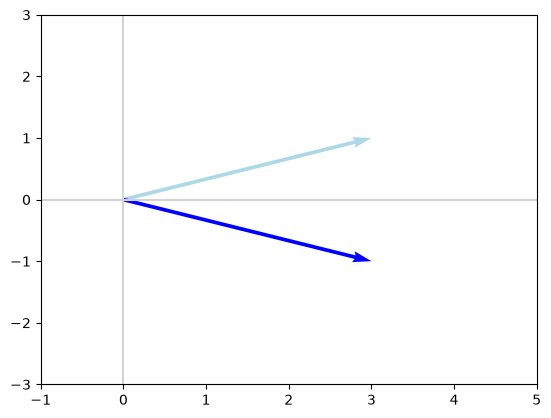

In [ ]:
plot_vectors([v, Ev], ['lightblue', 'blue'])
plt.xlim(-1, 5)
_ = plt.ylim(-3, 3)

O, esta matriz, $F$, que voltea vectores sobre el eje $y$:

In [ ]:
F = np.array([[-1, 0], [0, 1]])
F

array([[-1,  0],
       [ 0,  1]])

In [ ]:
Fv = np.dot(F, v)
Fv

array([-3,  1])

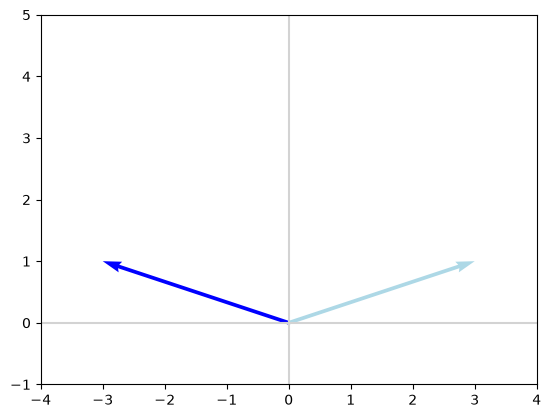

In [ ]:
plot_vectors([v, Fv], ['lightblue', 'blue'])
plt.xlim(-4, 4)
_ = plt.ylim(-1, 5)

Aplicar una matriz de volteo es un ejemplo de **transformación afín**: un cambio en la geometría que puede ajustar distancias o ángulos entre vectores, pero preserva el paralelismo entre ellos.

Además de voltear una matriz sobre un eje (también conocido como *reflexión*), otras transformaciones afines comunes incluyen:

* *Escalado* (cambiando la longitud de los vectores)
* *Cizallamiento* (cambiando la longitud de los vectores como veremos con la Mona Lisa)
* Rotación

(Ver [aquí](https://stackabuse.com/affine-image-transformations-in-python-with-numpy-pillow-and-opencv/) para una destacada entrada de blog sobre transformaciones afines en Python, incluyendo cómo aplicarlas tanto a imágenes como a vectores).

Una sola matriz puede aplicar múltiples transformaciones afines simultáneamente (por ejemplo, voltear sobre un eje y rotar 45 grados). Como ejemplo, veamos qué ocurre cuando aplicamos esta matriz $A$ al vector $v$:

In [ ]:
A = np.array([[-1, 4], [2, -2]])
A

array([[-1,  4],
       [ 2, -2]])

In [ ]:
Av = np.dot(A, v)
Av

array([1, 4])

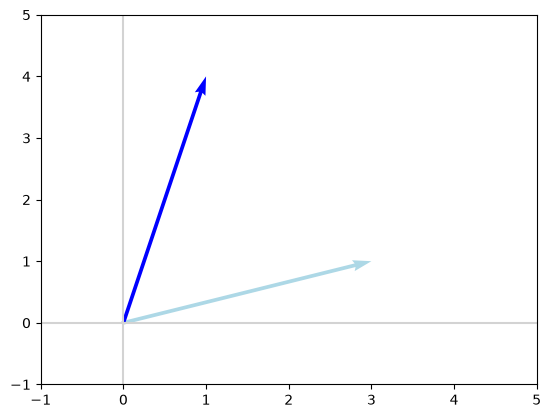

In [ ]:
plot_vectors([v, Av], ['lightblue', 'blue'])
plt.xlim(-1, 5)
_ = plt.ylim(-1, 5)

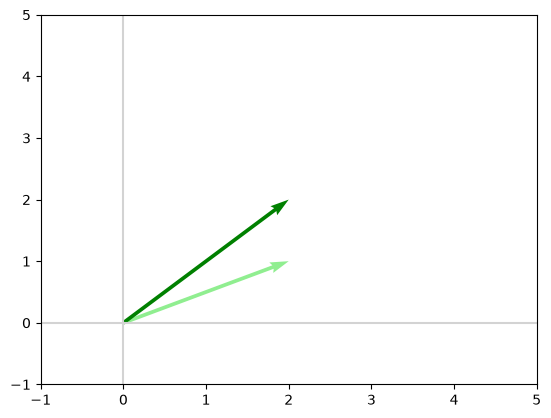

In [ ]:
# Otro ejemplo de aplicar la matriz A:
v2 = np.array([2, 1])
plot_vectors([v2, np.dot(A, v2)], ['lightgreen', 'green'])
plt.xlim(-1, 5)
_ = plt.ylim(-1, 5)

Podemos concatenar varios vectores juntos en una matriz (digamos, $V$), donde cada columna es un vector independiente. Entonces, cualquier transformación lineal que apliquemos a $V$ se aplicará independientemente a cada columna (vector):

In [ ]:
v

array([3, 1])

In [ ]:
# recordemos que necesitamos convertir array a 2D para transponer en columna, p.e:
np.matrix(v).T

matrix([[3],
        [1]])

In [ ]:
v3 = np.array([-3, -1]) # imagen especular de v en ambos ejes
v4 = np.array([-1, 1])

In [ ]:
V = np.concatenate((np.matrix(v).T,
                    np.matrix(v2).T,
                    np.matrix(v3).T,
                    np.matrix(v4).T),
                   axis=1)
V

matrix([[ 3,  2, -3, -1],
        [ 1,  1, -1,  1]])

In [ ]:
IV = np.dot(I, V)
IV

matrix([[ 3,  2, -3, -1],
        [ 1,  1, -1,  1]])

In [ ]:
AV = np.dot(A, V)
AV

matrix([[ 1,  2, -1,  5],
        [ 4,  2, -4, -4]])

In [ ]:
# función para convertir una columna de matriz en un vector 1D:
def vectorfy(mtrx, clmn):
    return np.array(mtrx[:,clmn]).reshape(-1)

In [ ]:
vectorfy(V, 0)

array([3, 1])

In [ ]:
vectorfy(V, 0) == v

array([ True,  True])

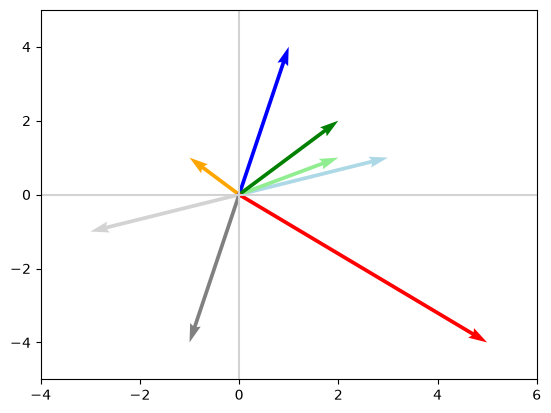

In [ ]:
plot_vectors([vectorfy(V, 0), vectorfy(V, 1), vectorfy(V, 2), vectorfy(V, 3),
             vectorfy(AV, 0), vectorfy(AV, 1), vectorfy(AV, 2), vectorfy(AV, 3)],
            ['lightblue', 'lightgreen', 'lightgray', 'orange',
             'blue', 'green', 'gray', 'red'])
plt.xlim(-4, 6)
_ = plt.ylim(-5, 5)

Ahora que podemos apreciar la transformación lineal de vectores por matrices, pasemos a trabajar con vectores y valores propios...

**Volver a las slides aquí.**

### Valores y Vectores Propios

Un **vector propio** (*eigen* en alemán significa «típico»; podríamos traducir *vector propio* por «vector característico») es un vector especial $v$ tal que cuando se transforma por alguna matriz (digamos $A$), el producto $Av$ tiene exactamente la misma dirección que $v$.

Un **valor propio** es un escalar (tradicionalmente representado como $\lambda$) que simplemente escala el vector propio $v$ de tal manera que se cumple la siguiente ecuación:

$Av = \lambda v$

**Cuidado con la notación** (es una confusión muy habitual, sobre todo en español): $V$ (mayúscula) es la matriz de **vectores** propios, *no* de «valores», aunque la letra pueda sugerirlo. Los **valores** propios son $\lambda$ (lambda). El propio código lo deja claro por el orden en que `eig()` devuelve las cosas: `lambdas, V = np.linalg.eig(A)` — primero los valores propios (`lambdas`), después la matriz de vectores propios (`V`).

La forma más fácil de entenderlo es a través de un ejemplo:

In [ ]:
A

array([[-1,  4],
       [ 2, -2]])

Los valores y vectores propios pueden derivarse algebraicamente (por ejemplo, con el [algoritmo QR](https://en.wikipedia.org/wiki/QR_algorithm), que fue desarrollado independientemente en los años 50 por [Vera Kublanovskaya](https://en.wikipedia.org/wiki/Vera_Kublanovskaya) y John Francis), sin embargo esto está fuera del alcance de la serie *ML Foundations*. Haremos trampas con el método NumPy `eig()`, que devuelve una tupla de:

* un vector de valores propios
* una matriz de vectores propios

In [ ]:
lambdas, V = np.linalg.eig(A)

La matriz contiene tantos vectores propios como columnas de A:

In [ ]:
V # each column is a separate eigenvector v

array([[ 0.86011126+0.j, -0.76454754+0.j],
       [ 0.51010647+0.j,  0.64456735+0.j]])

Con un valor propio correspondiente para cada vector propio:

In [ ]:
lambdas

array([ 1.37228132+0.j, -4.37228132+0.j])

Confirmemos que $Av = \lambda v$ para el primer vector propio:

In [ ]:
v = V[:,0]
v

array([0.86011126+0.j, 0.51010647+0.j])

In [ ]:
lambduh = lambdas[0] # notar que "lambda" es una palabra reservada en Python
lambduh

np.complex128(1.3722813232690143+0j)

In [ ]:
Av = np.dot(A, v)
Av

array([1.18031462+0.j, 0.70000958+0.j])

In [ ]:
lambduh * v

array([1.18031462+0.j, 0.70000958+0.j])

/home/alejandro/Escritorio/Cursos/Fundamentos matematicos de Machine Learning/matematicas-ml/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/alejandro/Escritorio/Cursos/Fundamentos matematicos de Machine Learning/matematicas-ml/.venv/lib/python3.12/site-packages/matplotlib/collections.py:205: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)
/home/alejandro/Escritorio/Cursos/Fundamentos matematicos de Machine Learning/matematicas-ml/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)
/home/alejandro/Escritorio/Cursos/Fundamentos matematicos de Machine Learning/matematicas-ml/.venv/lib/python3.12/site-packages/matplotlib/transforms.py:1913: ComplexWarning: Casting complex values to real

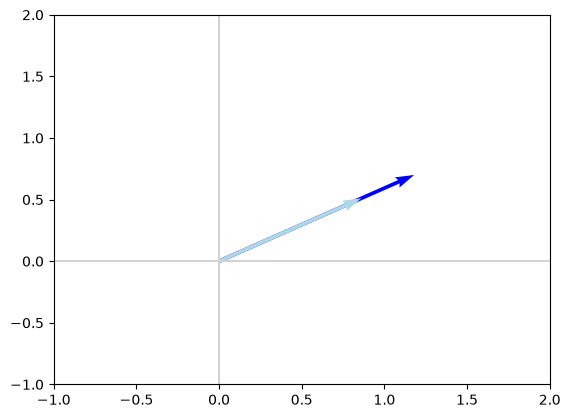

In [ ]:
plot_vectors([Av, v], ['blue', 'lightblue'])
plt.xlim(-1, 2)
_ = plt.ylim(-1, 2)

Y de nuevo para el segundo vector propio de A:

In [ ]:
v2 = V[:,1]
v2

array([-0.76454754+0.j,  0.64456735+0.j])

In [ ]:
lambda2 = lambdas[1]
lambda2

np.complex128(-4.372281323269014+0j)

In [ ]:
Av2 = np.dot(A, v2)
Av2

array([ 3.34281692+0.j, -2.81822977+0.j])

In [ ]:
lambda2 * v2

array([ 3.34281692-0.j, -2.81822977+0.j])

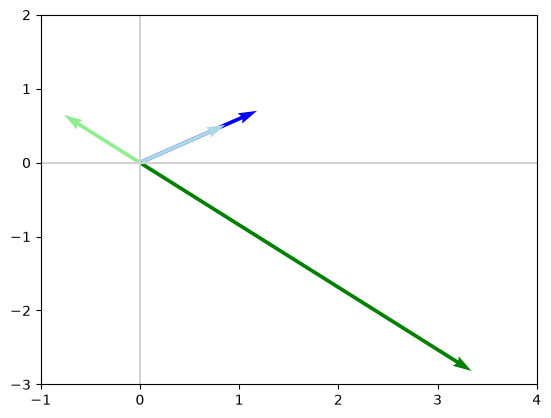

In [ ]:
plot_vectors([Av, v, Av2, v2],
            ['blue', 'lightblue', 'green', 'lightgreen'])
plt.xlim(-1, 4)
_ = plt.ylim(-3, 2)

Usando el método `eig()` de PyTorch, podemos hacer exactamente lo mismo:

In [146]:
A

array([[-1,  4],
       [ 2, -2]])

In [148]:
A_p = torch.tensor([[-1, 4], [2, -2.]]) # debe ser tipo float para poder usar PyTorch eig()
A_p

tensor([[-1.,  4.],
        [ 2., -2.]])

In [149]:
lambdas_cplx, V_cplx = torch.linalg.eig(A_p) # produce números complejos porque las matrices reales pueden tener vectores propios complejos

In [150]:
V_cplx # los valores de tipo complejo con parte imaginaria «0.j» son en realidad números reales

tensor([[ 0.8601+0.j, -0.7645+0.j],
        [ 0.5101+0.j,  0.6446+0.j]])

In [151]:
V_p = V_cplx.float()
V_p

/tmp/ipykernel_76046/1096125134.py:1: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/Copy.cpp:307.)
  V_p = V_cplx.float()


tensor([[ 0.8601, -0.7645],
        [ 0.5101,  0.6446]])

In [152]:
v_p = V_p[:,0]
v_p

tensor([0.8601, 0.5101])

In [153]:
lambdas_cplx

tensor([ 1.3723+0.j, -4.3723+0.j])

In [154]:
lambdas_p = lambdas_cplx.float()
lambdas_p

tensor([ 1.3723, -4.3723])

In [155]:
lambda_p = lambdas_p[0]
lambda_p

tensor(1.3723)

In [156]:
Av_p = torch.matmul(A_p, v_p) # matmul() espera tensores tipo float
Av_p

tensor([1.1803, 0.7000])

In [157]:
lambda_p * v_p

tensor([1.1803, 0.7000])

In [158]:
v2_p = V_p[:,1]
v2_p

tensor([-0.7645,  0.6446])

In [159]:
lambda2_p = lambdas_p[1]
lambda2_p

tensor(-4.3723)

In [160]:
Av2_p = torch.matmul(A_p.float(), v2_p.float())
Av2_p

tensor([ 3.3428, -2.8182])

In [161]:
lambda2_p.float() * v2_p.float()

tensor([ 3.3428, -2.8182])

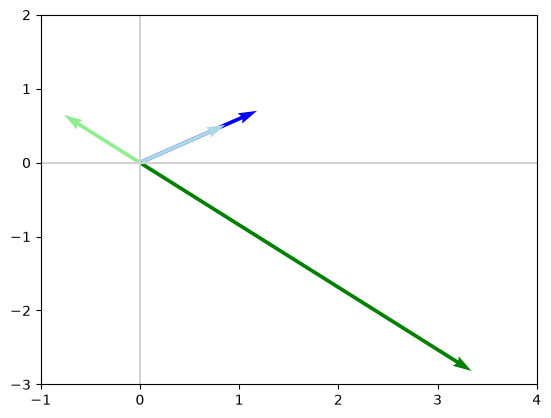

In [162]:
plot_vectors([Av_p.numpy(), v_p.numpy(), Av2_p.numpy(), v2_p.numpy()],
            ['blue', 'lightblue', 'green', 'lightgreen'])
plt.xlim(-1, 4)
_ = plt.ylim(-3, 2)

### Vectores Propios en dimensiones >2

Aunque la representación se complica en espacios de mayor dimensión, podemos encontrar y utilizar eigenvectores con más de dos dimensiones. He aquí un ejemplo en 3D (se manejan tres dimensiones en tres filas):

In [163]:
X = np.array([[25, 2, 9], [5, 26, -5], [3, 7, -1]])
X

array([[25,  2,  9],
       [ 5, 26, -5],
       [ 3,  7, -1]])

In [164]:
lambdas_X, V_X = np.linalg.eig(X)

In [165]:
V_X # cada vector propio en una de las columnas de X

array([[-0.71175736+0.j, -0.6501921 +0.j, -0.34220476+0.j],
       [-0.66652125+0.j,  0.74464056+0.j,  0.23789717+0.j],
       [-0.22170001+0.j,  0.15086635+0.j,  0.90901091+0.j]])

In [166]:
lambdas_X # un valor propio correspondiente para cada vector propio

array([29.67623202+0.j, 20.62117365+0.j, -0.29740567+0.j])

Confirmar que $Xv = \lambda v$ para un ejemplo de vector propio:

In [167]:
v_X = V_X[:,0]
v_X

array([-0.71175736+0.j, -0.66652125+0.j, -0.22170001+0.j])

In [168]:
lambda_X = lambdas_X[0]
lambda_X

np.complex128(29.676232023948916+0j)

In [169]:
np.dot(X, v_X) # producto de matrices

array([-21.12227645+0.j, -19.77983919+0.j,  -6.5792208 +0.j])

In [170]:
lambda_X * v_X

array([-21.12227645+0.j, -19.77983919+0.j,  -6.5792208 +0.j])

**Ejercicios**:

1. Utilizar PyTorch para confirmar $Xv = \lambda v$ para el primer vector propio de $X$.


In [171]:
X_p = torch.tensor([[25, 2, 9], [5, 26, -5], [3, 7, -1.]]) # debe ser tipo float para poder usar PyTorch eig()
lambdas_cplx, V_cplx = torch.linalg.eig(X_p) # produce números complejos porque las matrices reales pueden tener vectores propios complejos

In [172]:
V_p = V_cplx.float()
V_p

tensor([[ 0.7118,  0.6502, -0.3422],
        [ 0.6665, -0.7446,  0.2379],
        [ 0.2217, -0.1509,  0.9090]])

In [173]:
v_p = V_p[:, 0]
v_p

tensor([0.7118, 0.6665, 0.2217])

In [174]:
lambdas_p = lambdas_cplx.float()
lambdas_p

tensor([29.6762, 20.6212, -0.2974])

In [175]:
lambda_p = lambdas_p[0]
lambda_p

tensor(29.6762)

In [176]:
Xv_p = torch.matmul(X_p, v_p)
Xv_p

tensor([21.1223, 19.7798,  6.5792])

In [177]:
Lv_p = lambda_p * v_p
Lv_p

tensor([21.1223, 19.7798,  6.5792])

In [178]:
print(f"Xv = {np.round(Xv_p.numpy(), 4)} | λv = {np.round(Lv_p.numpy(), 4)} | ¿coinciden? {torch.allclose(Xv_p, Lv_p, atol=1e-3)}")

Xv = [21.1223 19.7798  6.5792] | λv = [21.1223 19.7798  6.5792] | ¿coinciden? True


*Nota: `X` es de 3x3, así que sus vectores propios tienen 3 componentes, pero `plot_vectors()` está pensada solo para 2D — el gráfico de abajo, por tanto, solo muestra 2 de las 3 componentes (ignora la tercera). La confirmación real de que $Xv=\lambda v$ es la comparación numérica de arriba, no el gráfico.*

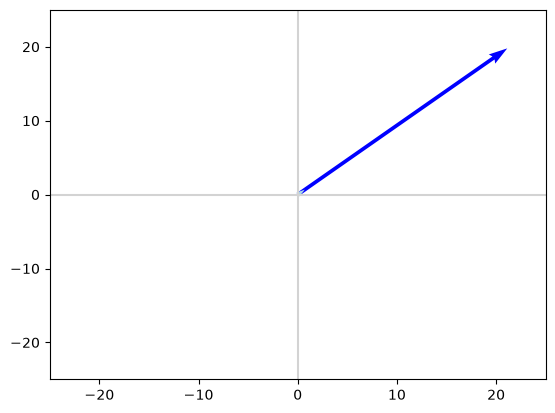

In [179]:
plot_vectors([Xv_p.numpy(), v_p.numpy()], ['blue', 'lightblue'])
plt.xlim(-25, 25)
_ = plt.ylim(-25, 25)

2. Confirmar $Xv = \lambda v$ para los restantes vectores propios de $X$ (se puede utilizar NumPy o PyTorch, lo que prefiera).

In [180]:
X = np.array([[25, 2, 9], [5, 26, -5], [3, 7, -1]])
X

array([[25,  2,  9],
       [ 5, 26, -5],
       [ 3,  7, -1]])

In [181]:
lambdas_X, V_X = np.linalg.eig(X)

In [182]:
v_X_0 = V_X[:,0]
v_X_0

array([-0.71175736+0.j, -0.66652125+0.j, -0.22170001+0.j])

In [183]:
lambda_X_0 = lambdas_X[0]
lambda_X_0

np.complex128(29.676232023948916+0j)

In [184]:
Xv_0=np.dot(X, v_X_0) # producto de matrices

In [185]:
Lv_0=lambda_X_0 * v_X_0

In [186]:
v_X_1 = V_X[:,1]
v_X_1

array([-0.6501921 +0.j,  0.74464056+0.j,  0.15086635+0.j])

In [196]:
lambda_X_1 = lambdas_X[1]
lambda_X_1

np.complex128(20.621173650535347+0j)

In [197]:
Xv_1=np.dot(X, v_X_1) # producto de matrices

In [189]:
Lv_1=lambda_X_1 * v_X_1

In [190]:
v_X_2 = V_X[:,2]
v_X_2

array([-0.34220476+0.j,  0.23789717+0.j,  0.90901091+0.j])

In [191]:
lambda_X_2 = lambdas_X[2]
lambda_X_2

np.complex128(-0.2974056744842649+0j)

In [192]:
Xv_2=np.dot(X, v_X_2) # producto de matrices

In [193]:
Lv_2=lambda_X_2 * v_X_2

In [199]:
for k, (Xv_k, Lv_k) in enumerate([(Xv_0, Lv_0), (Xv_1, Lv_1), (Xv_2, Lv_2)]):
    print(f"Vector propio {k}: Xv = {np.round(Xv_k.real, 4)} | λv = {np.round(Lv_k.real, 4)} "
          f"| ¿coinciden? {np.allclose(Xv_k, Lv_k)}")

Vector propio 0: Xv = [-21.1223 -19.7798  -6.5792] | λv = [-21.1223 -19.7798  -6.5792] | ¿coinciden? True
Vector propio 1: Xv = [-13.4077  15.3554   3.111 ] | λv = [-13.4077  15.3554   3.111 ] | ¿coinciden? True
Vector propio 2: Xv = [ 0.1018 -0.0708 -0.2703] | λv = [ 0.1018 -0.0708 -0.2703] | ¿coinciden? True


*Nota: al igual que antes, `X` es de 3x3, así que estos gráficos sólo muestran 2 de las 3 componentes de cada vector propio (limitación de `plot_vectors()`, pensada para 2D). La comparación numérica de arriba es la confirmación real de que $Xv=\lambda v$ para los tres vectores propios.*

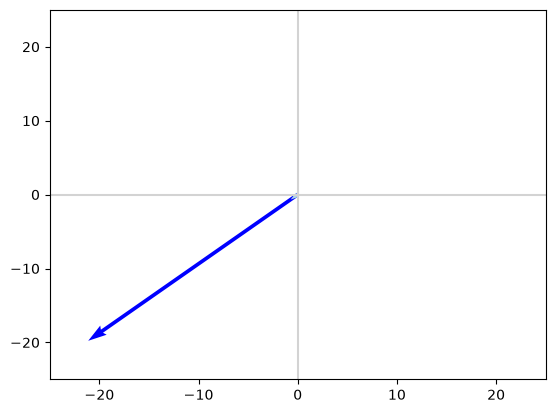

In [200]:
plot_vectors([Xv_0, v_X_0], ['blue', 'lightblue'])
plt.xlim(-25, 25)
_ = plt.ylim(-25, 25)

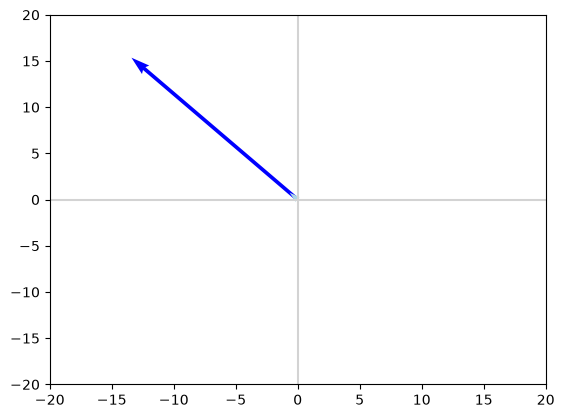

In [201]:
plot_vectors([Xv_1, v_X_1], ['blue', 'lightblue'])
plt.xlim(-20, 20)
_ = plt.ylim(-20, 20)

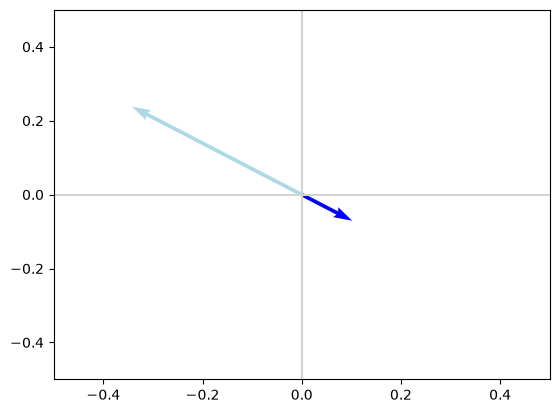

In [202]:
plot_vectors([Xv_2, v_X_2], ['blue', 'lightblue'])
plt.xlim(-0.5, 0.5)
_ = plt.ylim(-0.5, 0.5)

**Volver a las slides aquí.**

### Determinantes de Matrices 2x2

El **determinante** de una matriz cuadrada, denotado $\det(A)$ o $|A|$, es un único número que resume información clave sobre la transformación que representa esa matriz — en concreto, **el factor por el que se escala el área** (en 2D) o el **volumen** (en dimensiones superiores) al aplicar $A$.

Para una matriz $2\times2$, $A = \begin{bmatrix}a & b\\ c & d\end{bmatrix}$, se calcula como:

$$ \det(A) = ad - bc $$

Algunas propiedades importantes que iremos comprobando en esta sección:

* Si $\det(A) = 0$, la matriz **no tiene inversa** (es *singular*): «aplasta» el espacio en una dimensión menor, y por tanto pierde información sin remedio.
* El signo del determinante indica si la transformación **preserva o invierte la orientación** del espacio (positivo = preserva, negativo = invierte, como un reflejo).
* El valor absoluto $|\det(A)|$ es el factor de escala del área/volumen.

Por ejemplo si una matriz tiene determinante 2 al aplicar dicha matriz a otro vector pues se duplicara el vector el vector [1,2] pasara a [2,4]. Si es negativo pues invertira la direccion del vector es decir si el vector apunta hacia arriba pues ahora hacia abajo

In [203]:
X = np.array([[4, 2], [-5, -3]])
X

array([[ 4,  2],
       [-5, -3]])

In [204]:
np.linalg.det(X)

np.float64(-2.0000000000000013)

**Volver a las slides aquí.**

In [205]:
N = np.array([[-4, 1], [-8, 2]])
N

array([[-4,  1],
       [-8,  2]])

In [206]:
np.linalg.det(N)

np.float64(0.0)

In [207]:
# Descomentar la línea siguiente da lugar a un error de "matriz singular"
# Ninv = np.linalg.inv(N)

In [208]:
N = torch.tensor([[-4, 1], [-8, 2.]]) # must use float not int

In [209]:
torch.det(N)

tensor(-0.)

**Volver a las slides aquí.**

### Generalización de los Determinantes

La fórmula $ad-bc$ es específica de matrices $2\times2$; para matrices más grandes, el cálculo se generaliza (por ejemplo, mediante expansión por cofactores o eliminación gaussiana), pero la interpretación geométrica es la misma: sigue siendo el factor de escala del volumen en el espacio de $n$ dimensiones correspondiente. NumPy lo calcula por nosotros con `np.linalg.det()` independientemente del tamaño de la matriz.

In [211]:
X = np.array([[1, 2, 4], [2, -1, 3], [0, 5, 1]])
X

array([[ 1,  2,  4],
       [ 2, -1,  3],
       [ 0,  5,  1]])

In [212]:
np.linalg.det(X)

np.float64(19.999999999999996)

**Volver a las slides aquí.**

### Determinantes y valores propios

Recordando que lambda es el valor propio y V el vector propio aplicando el producto punto sobre el vector de los valores propios podemos obtener el determinante

In [270]:
lambdas, V = np.linalg.eig(X)
lambdas

array([-3.25599251+0.j, -1.13863631+0.j,  5.39462882+0.j])

In [271]:
np.prod(lambdas)

np.complex128(19.99999999999999+0j)

Efectivamente, coincide (salvo un pequeñísimo error de redondeo) con el determinante de $X$ que calculamos antes ($\approx 20$): **el determinante de una matriz es siempre igual al producto de sus valores propios**. Es, de hecho, otra forma de ver por qué un valor propio igual a 0 implica determinante 0 (matriz singular, sin inversa).

**Volver a las slides aquí.**

Aquí tenemos $|\text{det}(X)|$ en NumPy:

In [272]:
np.abs(np.linalg.det(X))

np.float64(19.999999999999996)

Vamos a utilizar una matriz $B$, que se compone de vectores base, para explorar el impacto de la aplicación de matrices con diferentes valores $|\text{det}(X)|$:

In [273]:
B = np.array([[1, 0], [0, 1]])
B

array([[1, 0],
       [0, 1]])

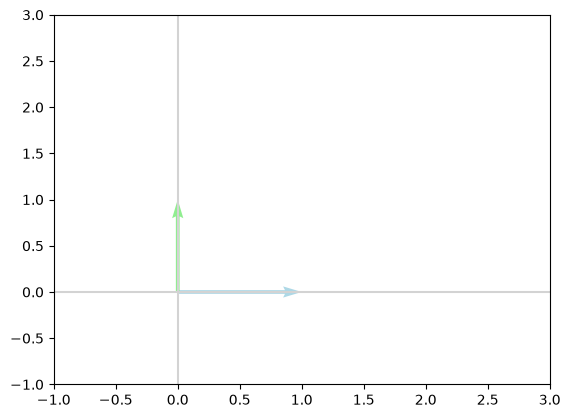

In [274]:
plot_vectors([vectorfy(B, 0), vectorfy(B, 1)],
            ['lightblue', 'lightgreen'])
plt.xlim(-1, 3)
_ = plt.ylim(-1, 3)

Empecemos aplicando la matriz $N$ a $B$, recordando de antes que $N$ es singular:

In [275]:
N

tensor([[-4.,  1.],
        [-8.,  2.]])

In [276]:
np.linalg.det(N)

np.float32(0.0)

In [277]:
NB = np.dot(N, B)
NB

/tmp/ipykernel_76046/2361209457.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  NB = np.dot(N, B)


array([[-4.,  1.],
       [-8.,  2.]])

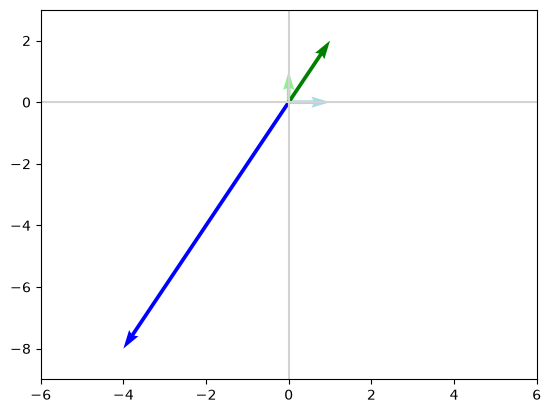

In [278]:
plot_vectors([vectorfy(B, 0), vectorfy(B, 1), vectorfy(NB, 0), vectorfy(NB, 1)],
            ['lightblue', 'lightgreen', 'blue', 'green'])
plt.xlim(-6, 6)
_ = plt.ylim(-9, 3)

In [279]:
lambdas, V = np.linalg.eig(N)
lambdas

array([-2.+0.j,  0.+0.j], dtype=complex64)

Si cualquiera de los valores propios de una matriz es cero, entonces el producto de los valores propios debe ser cero y el determinante también debe ser cero.

Vamos a aplicar $I_2$ a $B$:

In [280]:
I

array([[1, 0],
       [0, 1]])

In [281]:
np.linalg.det(I)

np.float64(1.0)

In [282]:
IB = np.dot(I, B)
IB

array([[1, 0],
       [0, 1]])

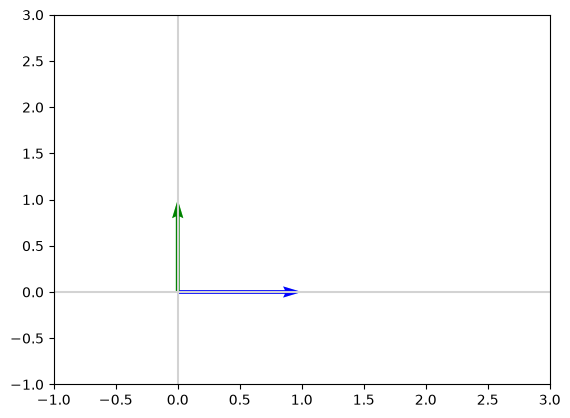

In [283]:
plot_vectors([vectorfy(B, 0), vectorfy(B, 1), vectorfy(IB, 0), vectorfy(IB, 1)],
            ['lightblue', 'lightgreen', 'blue', 'green'])
plt.xlim(-1, 3)
_ = plt.ylim(-1, 3)

In [284]:
lambdas, V = np.linalg.eig(I)
lambdas

array([1.+0.j, 1.+0.j])

Muy bien, aplicar una matriz identidad no es la operación más excitante del mundo. Ahora vamos a aplicar esta matriz $J$ que es más interesante:

In [285]:
J = np.array([[-0.5, 0], [0, 2]])
J

array([[-0.5,  0. ],
       [ 0. ,  2. ]])

In [286]:
np.linalg.det(J)

np.float64(-1.0)

In [287]:
np.abs(np.linalg.det(J))

np.float64(1.0)

In [288]:
JB = np.dot(J, B)
JB

array([[-0.5,  0. ],
       [ 0. ,  2. ]])

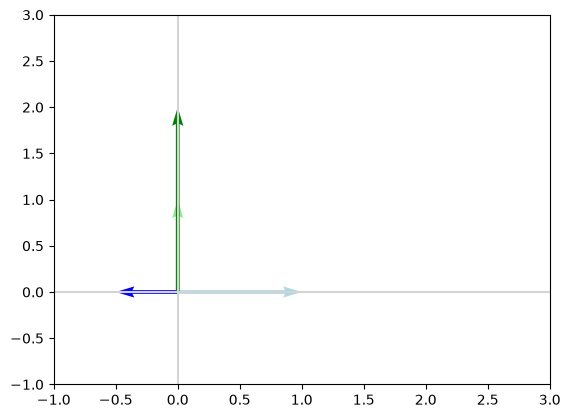

In [289]:
plot_vectors([vectorfy(B, 0), vectorfy(B, 1), vectorfy(JB, 0), vectorfy(JB, 1)],
            ['lightblue', 'lightgreen', 'blue', 'green'])
plt.xlim(-1, 3)
_ = plt.ylim(-1, 3)

In [290]:
lambdas, V = np.linalg.eig(J)
lambdas

array([-0.5+0.j,  2. +0.j])

Por último, apliquemos la matriz $D$, que escala los vectores doblando a lo largo de los ejes $x$ e $y$:

In [291]:
D = I*2
D

array([[2, 0],
       [0, 2]])

In [292]:
np.linalg.det(D)

np.float64(4.0)

In [293]:
DB = np.dot(D, B)
DB

array([[2, 0],
       [0, 2]])

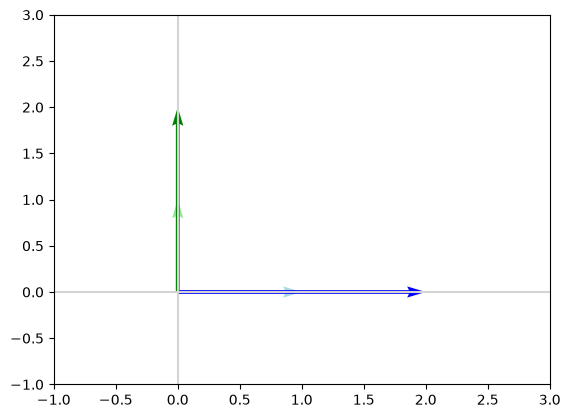

In [294]:
plot_vectors([vectorfy(B, 0), vectorfy(B, 1), vectorfy(DB, 0), vectorfy(DB, 1)],
            ['lightblue', 'lightgreen', 'blue', 'green'])
plt.xlim(-1, 3)
_ = plt.ylim(-1, 3)

In [295]:
lambdas, V = np.linalg.eig(D)
lambdas

array([2.+0.j, 2.+0.j])

**Volver a las slides aquí.**

### Descomposición Propia

La **descomposición propia** de alguna matriz $A$ es

$A = V \Lambda V^{-1}$

Donde:

* Como en los ejemplos anteriores, $V$ es la concatenación de todos los vectores propios de $A$
* $\Lambda$ ($\lambda$ en mayúsculas) es la matriz diagonal diag($\lambda$). Obsérvese que la convención es ordenar los valores lambda en orden descendente; como resultado, el primer valor propio (y su vector propio asociado) puede ser una característica primaria de la matriz $A$.

In [300]:
# Esto se utilizó anteriormente como una matriz X; tiene bonitos y limpios valores propios enteros...
A = np.array([[4, 2], [-5, -3]])
A

array([[ 4,  2],
       [-5, -3]])

In [301]:
np.linalg.det(A)

np.float64(-2.0000000000000013)

In [302]:
lambdas, V = np.linalg.eig(A)

In [303]:
V

array([[ 0.70710678+0.j, -0.37139068+0.j],
       [-0.70710678+0.j,  0.92847669+0.j]])

In [304]:
Vinv = np.linalg.inv(V)
Vinv

array([[2.3570226 +0.j, 0.94280904+0.j],
       [1.79505494+0.j, 1.79505494+0.j]])

In [305]:
Lambda = np.diag(lambdas)
Lambda

array([[ 2.+0.j,  0.+0.j],
       [ 0.+0.j, -1.+0.j]])

Confirmamos que $A = V \Lambda V^{-1}$:

In [306]:
np.dot(V, np.dot(Lambda, Vinv))

array([[ 4.+0.j,  2.+0.j],
       [-5.+0.j, -3.+0.j]])

**¿Para qué sirve esto?** Reconstruir $A$ a partir de $V$, $\Lambda$ y $V^{-1}$ es solo la comprobación de que la descomposición es correcta — la utilidad real está en que $\Lambda$ es **diagonal**, y las matrices diagonales son mucho más baratas de manipular que $A$ en general. Algunos usos concretos:

* **Potencias de una matriz**: $A^n = V\Lambda^n V^{-1}$. Elevar una matriz diagonal a $n$ es trivial (solo elevar cada valor de la diagonal), mucho más barato que multiplicar $A$ por sí misma $n$ veces — clave en sistemas dinámicos, cadenas de Markov y redes neuronales recurrentes.
* **Comportamiento a largo plazo / estabilidad**: al aplicar $A$ repetidamente, cualquier vector tiende a alinearse con el vector propio del mayor valor propio, creciendo o decayendo según si $|\lambda|>1$ o $|\lambda|<1$. Es la idea detrás de algoritmos como **PageRank**.
* **PCA** (lo veremos más adelante en este notebook): se aplica esta misma descomposición a la matriz de covarianza de un dataset. Los vectores propios son las direcciones de máxima varianza; los valores propios, cuánta varianza explica cada una.
* **Invertir $A$ más barato**: $A^{-1} = V\Lambda^{-1}V^{-1}$, y $\Lambda^{-1}$ es solo invertir cada elemento de la diagonal.

La descomposición propia no es posible con todas las matrices. Y en algunos casos en los que es posible, la descomposición propia implica números complejos en lugar de números reales directos.

En el aprendizaje automático, sin embargo, normalmente trabajamos con matrices simétricas reales (recordemos que una matriz simetrica es aquella cuya traspuesta es igual a la original), que pueden descomponerse de forma conveniente y eficiente en vectores propios sólo reales y valores propios sólo reales. Si $A$ es una matriz simétrica real entonces...

$A = Q \Lambda Q^T$

...donde $Q$ es análoga a $V$ de la ecuación anterior excepto que es especial porque es una matriz ortogonal.

$Q$ es la misma matriz de vectores propios de siempre (antes llamada $V$); solo cambia de nombre para avisarnos de algo importante: cuando $A$ es simétrica, sus vectores propios siempre salen **ortogonales(2 vectores son otogonales si el producto escalar es 0 lo que indica que tienen un angulo de 90º entre si lo que significa que son perpendiculares)** entre sí (esto está garantizado matemáticamente, no es casualidad). Y como para una matriz ortogonal ya sabemos que $Q^{-1}=Q^T$, en vez de calcular la inversa (costosa) simplemente transponemos (gratis) — por eso se escribe $Q\Lambda Q^T$ en lugar de $Q\Lambda Q^{-1}$. Recordemos que para ser ortonormal ademas de ortogonal la norma(la magnitud, longitud o tamaño de un vector) de los 2 vectores debe ser 1

In [307]:
A = np.array([[2, 1], [1, 2]])
A

array([[2, 1],
       [1, 2]])

In [308]:
lambdas, Q = np.linalg.eig(A)

In [309]:
lambdas

array([3.+0.j, 1.+0.j])

In [310]:
Lambda = np.diag(lambdas)
Lambda

array([[3.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j]])

In [311]:
Q

array([[ 0.70710678+0.j, -0.70710678+0.j],
       [ 0.70710678+0.j,  0.70710678+0.j]])

Confirmemos que $A = Q \Lambda Q^T$:

In [312]:
np.dot(Q, np.dot(Lambda, Q.T))

array([[2.+0.j, 1.+0.j],
       [1.+0.j, 2.+0.j]])

(Como apunte rápido, podemos demostrar que $Q$ es una matriz ortogonal porque $Q^TQ = QQ^T = I$).

In [313]:
np.dot(Q.T, Q)

array([[1.00000000e+00+0.j, 2.23711432e-17+0.j],
       [2.23711432e-17+0.j, 1.00000000e+00+0.j]])

In [314]:
np.dot(Q, Q.T)

array([[ 1.00000000e+00+0.j, -2.23711432e-17+0.j],
       [-2.23711432e-17+0.j,  1.00000000e+00+0.j]])

**Ejercicios**:

1. Utiliza PyTorch para descomponer la matriz $P$ (abajo) en sus componentes $V$, $\Lambda$, y $V^{-1}$. Confirmar que $P = V \Lambda V^{-1}$.


In [321]:
P = torch.tensor([[25, 2, -5], [3, -2, 1], [5, 7, 4.]])
P

tensor([[25.,  2., -5.],
        [ 3., -2.,  1.],
        [ 5.,  7.,  4.]])

In [323]:
lambdas, V = torch.linalg.eig(P)
lambdas = torch.diag(lambdas)

In [325]:
V_inv = torch.linalg.inv(V)

torch.linalg.matmul(V, torch.linalg.matmul(lambdas, V_inv))

tensor([[25.0000+0.j,  2.0000+0.j, -5.0000+0.j],
        [ 3.0000+0.j, -2.0000+0.j,  1.0000+0.j],
        [ 5.0000+0.j,  7.0000+0.j,  4.0000+0.j]])

2. Utilizar PyTorch para descomponer la matriz simétrica $S$ (abajo) en sus componentes $Q$, $\Lambda$ y $Q^T$. Confirmar que $S = Q \Lambda Q^T$.

In [338]:
S = torch.tensor([[25, 2, -5], [2, -2, 1], [-5, 1, 4.]])
S

tensor([[25.,  2., -5.],
        [ 2., -2.,  1.],
        [-5.,  1.,  4.]])

In [339]:
lambdas, Q = torch.linalg.eig(S)
lambdas = torch.diag(lambdas)

In [340]:
Q_T = Q.T

torch.linalg.matmul(Q, torch.linalg.matmul(lambdas, Q_T))

tensor([[25.0000+0.j,  2.0000+0.j, -5.0000+0.j],
        [ 2.0000+0.j, -2.0000+0.j,  1.0000+0.j],
        [-5.0000+0.j,  1.0000+0.j,  4.0000+0.j]])

**Volver a las slides aquí.**

## Segmento 3: Operaciones Matriciales en ML

### Descomposición en Valor Singular (SVD)

Como en las diapositivas, SVD de la matriz $A$ es:

$A = UDV^T$

Donde:

$U$ es una matriz ortogonal $m \times m$; sus columnas son los vectores singulares izquierdos de $A$.

$V$ es una matriz ortogonal $n \times n$; sus columnas son los vectores singulares derechos de $A$ (igual que en $U$: son las columnas, no las filas — ojo si miras VT en el código, que es $V$ ya transpuesta, ahí sí son las filas).

$D$ es una matriz diagonal $m \times n$; los elementos a lo largo de su diagonal son los valores singulares de $A$.

(«Izquierdo»/«derecho» es solo por su posición en la fórmula: $U$ va a la izquierda de $D$, $V^T$ a la derecha. Más adelante veremos que además coincide con algo más profundo: $U$ son los vectores propios de $AA^T$, y $V$ los de $A^TA$ — no de $A$ directamente.)





In [2]:
A = np.array([[-1, 2], [3, -2], [5, 7]])
A

array([[-1,  2],
       [ 3, -2],
       [ 5,  7]])

In [3]:
U, d, VT = np.linalg.svd(A) # V ya está transpuesta!

In [5]:
U

array([[ 0.12708324,  0.47409506,  0.87125411],
       [ 0.00164602, -0.87847553,  0.47778451],
       [ 0.99189069, -0.0592843 , -0.11241989]])

In [6]:
VT

array([[ 0.55798885,  0.82984845],
       [-0.82984845,  0.55798885]])

In [ ]:
d

array([8.66918448, 4.10429538])

In [ ]:
np.diag(d)

array([[8.66918448, 0.        ],
       [0.        , 4.10429538]])

$D$ debe tener las mismas dimensiones que $A$ para que sea posible la multiplicación de matrices $UDV^T$:


In [ ]:
D = np.concatenate((np.diag(d), [[0, 0]]), axis=0)
D

array([[8.66918448, 0.        ],
       [0.        , 4.10429538],
       [0.        , 0.        ]])

In [ ]:
np.dot(U, np.dot(D, VT))

array([[-1.,  2.],
       [ 3., -2.],
       [ 5.,  7.]])

La SVD y la eigencomposición están estrechamente relacionadas:

* Vectores singulares izquierdos de $A$ = vectores propios de $AA^T$.
* Vectores singulares derechos de $A$ = vectores propios de $A^TA$.
* Valores singulares no nulos de $A$ = raíces cuadradas de los valores propios de $AA^T$ = raíces cuadradas de los valores propios de $A^TA$.

**Ejercicio**: Utilizando la matriz `P` de los ejercicios PyTorch anteriores, demuestra que estas tres ecuaciones de SVD-eigendecomposición son ciertas.

In [7]:
P = np.array([[25, 2, -5], [3, -2, 1], [5, 7, 4.]])
P

array([[25.,  2., -5.],
       [ 3., -2.,  1.],
       [ 5.,  7.,  4.]])

In [8]:
U, d, VT = np.linalg.svd(P) 

In [9]:
U

array([[-0.97571953, -0.18227289, -0.1214413 ],
       [-0.09750433, -0.1350092 ,  0.9860352 ],
       [-0.19612318,  0.97393486,  0.11395871]])

In [11]:
VT

array([[-0.98099938, -0.11960649,  0.15275636],
       [-0.01125803,  0.82112714,  0.57063428],
       [ 0.19368396, -0.55807214,  0.80687174]])

In [18]:
d

array([26.16323489,  8.1875465 ,  2.53953194])

In [15]:
lambdas, V = np.linalg.eig(np.dot(P, P.T))
V

array([[-0.97571953+0.j, -0.18227289+0.j,  0.1214413 +0.j],
       [-0.09750433+0.j, -0.1350092 +0.j, -0.9860352 +0.j],
       [-0.19612318+0.j,  0.97393486+0.j, -0.11395871+0.j]])

In [16]:
lambdas, V = np.linalg.eig(np.dot(P.T, P))
V

array([[ 0.98099938+0.j,  0.19368396+0.j, -0.01125803+0.j],
       [ 0.11960649+0.j, -0.55807214+0.j,  0.82112714+0.j],
       [-0.15275636+0.j,  0.80687174+0.j,  0.57063428+0.j]])

In [17]:
lambdas, V = np.linalg.eig(np.dot(P.T, P))
np.sqrt(lambdas)

array([26.16323489+0.j,  2.53953194+0.j,  8.1875465 +0.j])

### Compresión de Imágenes con SVD

La sección presenta código adaptado de [Frank Cleary's](https://gist.github.com/frankcleary/4d2bd178708503b556b0).

In [ ]:
from PIL import Image


Foto de Oboe, el terrier de Jon Krohn, con el libro *Aprendizaje Profundo Ilustrado*:

In [20]:
! wget https://raw.githubusercontent.com/joanby/DLTFpT/master/notebooks/oboe-with-book.jpg

            _.-ppOOOOOOqq-._                alejandro@alejandro-A8-MAX
         .oOOOOPPPPPPPPPPOOOOo.             --------------------------
      .oOOOO.=oOOOOOOOOOOo=.OOOOo.          OS: Linux Mint 22.3 x86_64
    .:OOO.=oOOOOOOOOOOOOOOOOo=.OOO:.        Host: A8 MAX
   .OOO.OOOOOOOOOOOOOOOOOOOOOOOO.OOO.       Kernel: Linux 7.0.0-30-generic
  .OOO.OO    OOO:´   `::´    `:OOO.OO:      Uptime: 1 hour, 2 mins
 .OOO.OOO    OO                OOO.OOO:     Packages: 2919 (dpkg), 20 (flatpak)
 OOO.OOOO    OO    oo    oo    OOOO.OOO     Shell: fish 3.7.0
:OOO:OOOO    OO    OO    OO    OOOO:OOO:    Display (Smart M50D): 1920x1080 in 32", 60 Hz [External]
:OOO:OOOO    OO    OO    OO    OOOO:OOO:    Desktop Environment: Cinnamon 6.6.9
'OOO'OOOO    OO    OO    OO    OOOO'OOO'    Window Manager: Muffin (X11)
 OOO'OOOO    OO____OO____OO    OOOO'OOO'    WM Theme: WhiteSur-Dark-solid (Mint-Y)
 'OOO'OOO    'OOOOOOOOOOOO'    OOOO'OOO     Theme: WhiteSur-Dark-solid [GTK2/3/4]
  'OOO'OOO                 

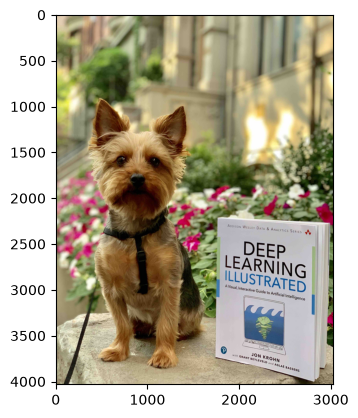

In [23]:
img = Image.open('oboe-with-book.jpg')
_ = plt.imshow(img)

Convertir la imagen a escala de grises para no tener que lidiar con la complejidad de múltiples canales de color:

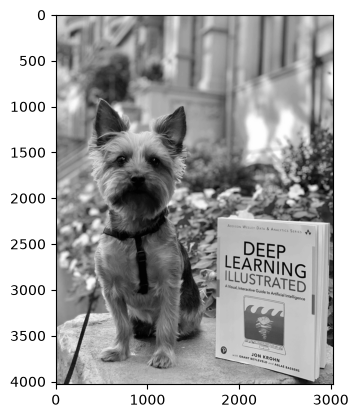

In [24]:
imggray = img.convert('LA')
_ = plt.imshow(imggray)

Convierte los datos en una matriz numpy, que no afecta a los datos de la imagen:

/tmp/ipykernel_18459/944952042.py:1: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  imgmat = np.array(list(imggray.getdata(band=0)), float)
/tmp/ipykernel_18459/944952042.py:2: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  imgmat.shape = (imggray.size[1], imggray.size[0])


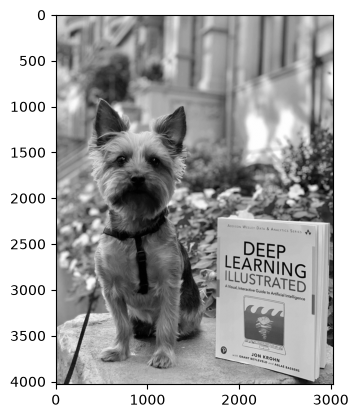

In [25]:
imgmat = np.array(list(imggray.getdata(band=0)), float)
imgmat.shape = (imggray.size[1], imggray.size[0])
imgmat = np.matrix(imgmat)
_ = plt.imshow(imgmat, cmap='gray')

Calcular la SVD de la imagen:

In [26]:
U, sigma, V = np.linalg.svd(imgmat)

Al igual que los valores propios se ordenan en orden descendente en diag($\lambda$), también los valores singulares, por convención, se ordenan en orden descendente en $D$ (o, en este código, diag($\sigma$)). Así, el primer vector singular izquierdo de $U$ y el primer vector singular derecho de $V$ pueden representar la característica más prominente de la imagen:

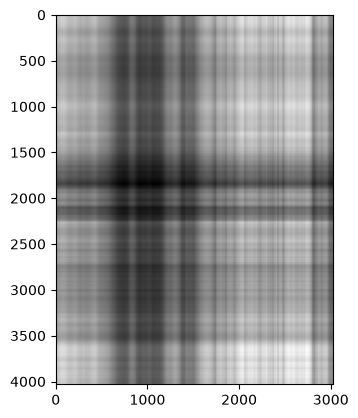

In [27]:
reconstimg = np.matrix(U[:, :1]) * np.diag(sigma[:1]) * np.matrix(V[:1, :])
_ = plt.imshow(reconstimg, cmap='gray')

Los vectores singulares adicionales mejoran la calidad de la imagen:

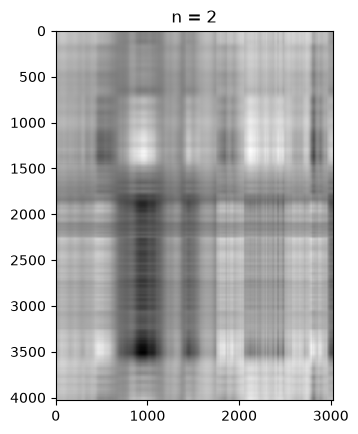

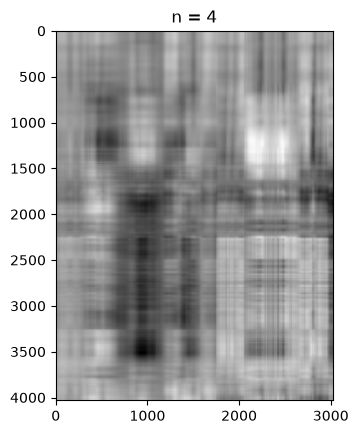

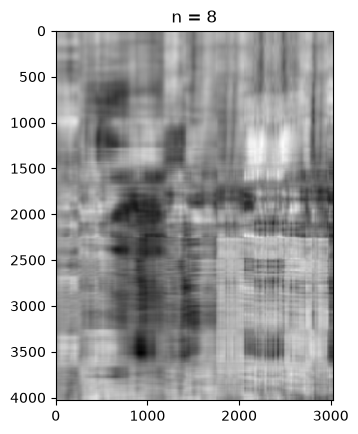

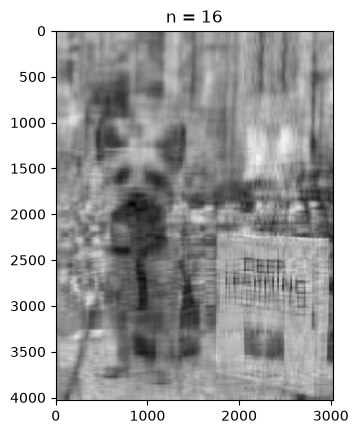

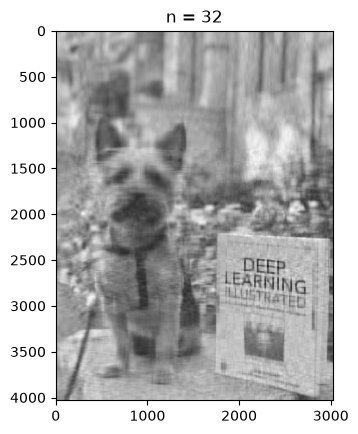

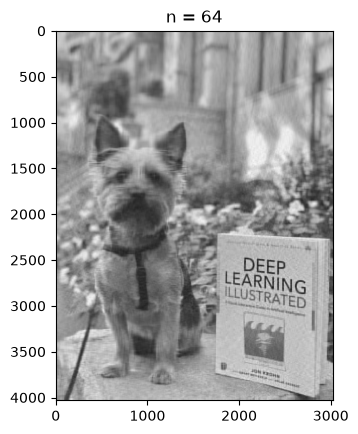

In [28]:
for i in [2, 4, 8, 16, 32, 64]:
    reconstimg = np.matrix(U[:, :i]) * np.diag(sigma[:i]) * np.matrix(V[:i, :])
    plt.imshow(reconstimg, cmap='gray')
    title = "n = %s" % i
    plt.title(title)
    plt.show()

Con 64 vectores singulares, la imagen se reconstruye bastante bien, aunque la huella de datos es mucho menor que la de la imagen original:

In [29]:
imgmat.shape

(4032, 3024)

In [32]:
full_representation = 4032*3024
full_representation

12192768

In [31]:
svd64_rep = 64*4032 + 64 + 64*3024
svd64_rep

451648

In [34]:
svd64_rep/full_representation

0.037042286050222556

En concreto, la imagen representada como 64 vectores singulares ocupa el 3,7% del tamaño del original.

Además de imágenes, podemos utilizar vectores singulares para la compresión con pérdidas de otros tipos de archivos multimedia.

**Volver a las slides aquí.**

### La Pseudoinversa de Moore-Penrose

La inversa normal $A^{-1}$ solo existe si $A$ es cuadrada y sus columnas son independientes. La **pseudoinversa** $A^+$ generaliza esa idea a **cualquier matriz**: si el sistema $Aw=y$ tiene más ecuaciones que incógnitas (como en una regresión, con muchas filas y pocas columnas), $A^+$ da la solución que **minimiza el error cuadrático** — es decir, resolver $w=A^+y$ es equivalente a la ecuación normal $w=(A^TA)^{-1}A^Ty$ que ya usamos en la regresión de precios de casas, pero calculado de forma más estable numéricamente (vía SVD, en vez de invirtiendo $A^TA$ directamente).

Vamos a calcular el pseudoinverso $A^+$ de alguna matriz $A$ utilizando la fórmula de las diapositivas:

$A^+ = VD^+U^T$

In [51]:
A

array([[-1,  2],
       [ 3, -2],
       [ 5,  7]])

Como se mostró anteriormente, el método NumPy SVD devuelve $U$, $d$ y $V^T$:

In [52]:
U, d, VT = np.linalg.svd(A)

In [53]:
U

array([[ 0.12708324,  0.47409506,  0.87125411],
       [ 0.00164602, -0.87847553,  0.47778451],
       [ 0.99189069, -0.0592843 , -0.11241989]])

In [54]:
VT

array([[ 0.55798885,  0.82984845],
       [-0.82984845,  0.55798885]])

In [55]:
d

array([8.66918448, 4.10429538])

Para crear $D^+$, primero invertimos los valores distintos de cero de $d$:

In [63]:
D = np.diag(d)
D

array([[8.66918448, 0.        ],
       [0.        , 4.10429538]])

In [41]:
1/8.669

0.11535355865728457

In [42]:
1/4.104

0.24366471734892786

...y luego tomaríamos el tranpuesto de la matriz resultante.

Como $D$ es una matriz diagonal, esto se puede hacer en un solo paso invirtiendo $D$:

In [57]:
Dinv = np.linalg.inv(D)
Dinv

array([[0.1153511 , 0.        ],
       [0.        , 0.24364718]])

$D^+$ debe tener las mismas dimensiones que $A^T$ para que sea posible la multiplicación de matrices $VD^+U^T$:

In [58]:
Dplus = np.concatenate((Dinv, np.array([[0, 0]]).T), axis=1)
Dplus

array([[0.1153511 , 0.        , 0.        ],
       [0.        , 0.24364718, 0.        ]])

(Recordemos que $D$ debe tener las mismas dimensiones que $A$ para $UDV^T$ de SVD, pero para MPP $U$ y $V$ han intercambiado lados alrededor de la matriz diagonal).

Ahora tenemos todo lo que necesitamos para calcular $A^+$ con $VD^+U^T$:

In [59]:
np.dot(VT.T, np.dot(Dplus, U.T))

array([[-0.08767773,  0.17772512,  0.07582938],
       [ 0.07661927, -0.1192733 ,  0.08688784]])

Trabajar esta derivación es útil para entender cómo funcionan los pseudoinversos de Moore-Penrose, pero como era de esperar NumPy se carga con un método existente `pinv()`:

In [60]:
np.linalg.pinv(A)

array([[-0.08767773,  0.17772512,  0.07582938],
       [ 0.07661927, -0.1192733 ,  0.08688784]])

**Ejercicio**

Utiliza el método `torch.svd()` para calcular el pseudoinverso de `A_p`, confirmando que tu resultado coincide con la salida de `torch.pinverse(A_p)`:

In [49]:
A_p = torch.tensor([[-1, 2], [3, -2], [5, 7.]])
A_p

tensor([[-1.,  2.],
        [ 3., -2.],
        [ 5.,  7.]])

In [50]:
torch.pinverse(A_p)

tensor([[-0.0877,  0.1777,  0.0758],
        [ 0.0766, -0.1193,  0.0869]])

In [78]:
U_p, d_p, VT_p = torch.linalg.svd(A_p)

In [79]:
DP = torch.diag(d_p)
DP

tensor([[8.6692, 0.0000],
        [0.0000, 4.1043]])

In [80]:
DPinv = torch.linalg.inv(DP)
DPinv

tensor([[0.1154, 0.0000],
        [0.0000, 0.2436]])

In [81]:
Dplus = torch.cat((DPinv, torch.tensor([[0, 0]]).T), dim=1)
Dplus

tensor([[0.1154, 0.0000, 0.0000],
        [0.0000, 0.2436, 0.0000]])

In [82]:
torch.matmul(VT_p.T, torch.matmul(Dplus, U_p.T))

tensor([[-0.0877,  0.1777,  0.0758],
        [ 0.0766, -0.1193,  0.0869]])

**Volver a las slides aquí.**

En los problemas de regresión, normalmente tenemos muchos más casos ($n$, o filas de $X$) que características a predecir (columnas de $X$). Es decir, $X$ casi nunca es cuadrada, así que $X^{-1}$ **no existe** — y aquí es exactamente donde entra en juego la pseudoinversa $X^+$ que acabamos de calcular a mano.

Resolvamos un ejemplo en miniatura de tal situación de sobredeterminación: un ensayo clínico con 8 pacientes ($n=8$), en el que queremos predecir el «olvido» a partir de la dosis de un fármaco.

In [83]:
x1 = [0, 1, 2, 3, 4, 5, 6, 7.] # E.g.: Dosage of drug for treating Alzheimer's disease
y = [1.86, 1.31, .62, .33, .09, -.67, -1.23, -1.37] # E.g.: Patient's "forgetfulness score"

In [84]:
title = 'Ensayo Clínico'
xlabel = 'Dosis del Fármaco (mL)'
ylabel = 'Olvido'

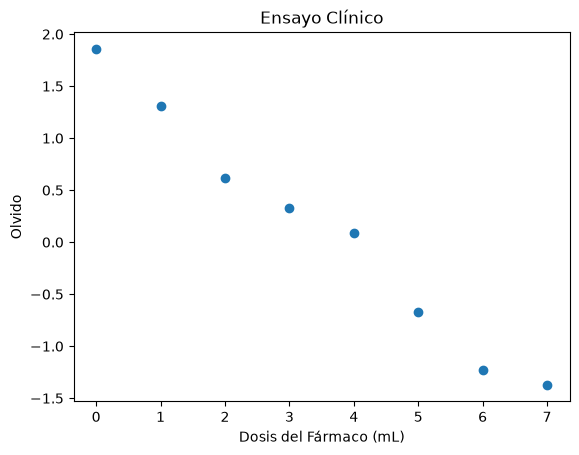

In [85]:
fig, ax = plt.subplots()
plt.title(title)
plt.xlabel(xlabel)
plt.ylabel(ylabel)
_ = ax.scatter(x1, y)

Aunque parece que sólo hay un predictor ($x_1$), nuestro modelo requiere un segundo (llamémoslo $x_0$) para permitir una intersección $y$ (el término independiente o *bias*, $b$). Sin esta segunda variable, la línea que ajustamos al gráfico tendría que pasar obligatoriamente por el origen $(0, 0)$. Como el término independiente es constante para todos los puntos, podemos representarlo con una columna de unos — la misma idea de **matriz de diseño** que usamos en la regresión de precios de casas del notebook 1:

In [86]:
x0 = np.ones(8)
x0

array([1., 1., 1., 1., 1., 1., 1., 1.])

Concatenar $x_0$ y $x_1$ en una matriz $X$:

In [87]:
X = np.concatenate((np.matrix(x0).T, np.matrix(x1).T), axis=1)
X

matrix([[1., 0.],
        [1., 1.],
        [1., 2.],
        [1., 3.],
        [1., 4.],
        [1., 5.],
        [1., 6.],
        [1., 7.]])

Por las diapositivas, sabemos que podemos calcular los pesos $w$ mediante la ecuación:

$$ w = X^+y $$

Esto es exactamente lo mismo que resolver la ecuación normal $w=(X^TX)^{-1}X^Ty$ que usamos en el notebook 1 — la pseudoinversa simplemente empaqueta ese cálculo en un solo paso (y de forma más estable numéricamente, al apoyarse en la SVD):

In [88]:
w = np.dot(np.linalg.pinv(X), y)
w

matrix([[ 1.76      , -0.46928571]])

Comprobemos esa equivalencia con las dos fórmulas, para que quede claro que no es solo una afirmación teórica:

In [ ]:
w_normal = np.dot(np.linalg.inv(np.dot(X.T, X)), np.dot(X.T, y))
print("w (pseudoinversa):   ", np.asarray(w).reshape(-1))
print("w (ecuación normal):", np.asarray(w_normal).reshape(-1))

w (pseudoinversa):    [ 1.76       -0.46928571]
w (ecuación normal): [ 1.76       -0.46928571]

$w$ tiene 2 componentes, una por cada columna de $X$. La primera ($w_0$, multiplicada siempre por $x_0=1$) es la intersección $y$ de la recta, que solemos llamar $b$:

In [91]:
b = np.asarray(w).reshape(-1)[0]
b

np.float64(1.7599999999999993)

Y la segunda ($w_1$, multiplicada por la dosis $x_1$) es la pendiente de la recta, que solemos denotar $m$ — es decir, cuánto cambia el «olvido» por cada mL adicional de fármaco:

In [92]:
m = np.asarray(w).reshape(-1)[1]
m

np.float64(-0.4692857142857141)

Con los pesos podemos trazar la recta para confirmar que se ajusta a los puntos:

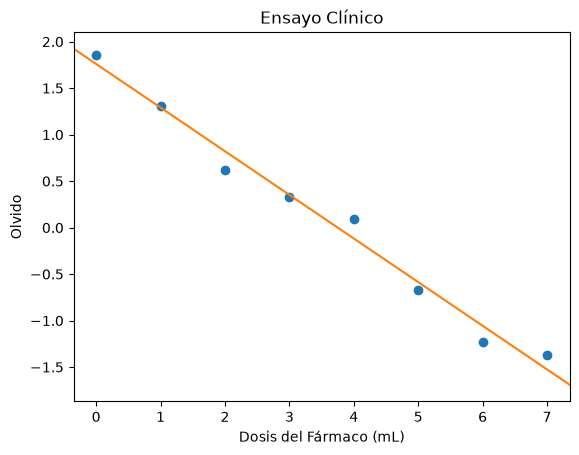

In [93]:
fig, ax = plt.subplots()

plt.title(title)
plt.xlabel(xlabel)
plt.ylabel(ylabel)

ax.scatter(x1, y)

x_min, x_max = ax.get_xlim()
y_at_xmin = m*x_min + b
y_at_xmax = m*x_max + b

ax.set_xlim([x_min, x_max])
_ = ax.plot([x_min, x_max], [y_at_xmin, y_at_xmax], c='C01')

La recta ajusta bien los 8 puntos — y fíjate en el paralelismo con el notebook 1: allí resolvimos $w=(X^TX)^{-1}X^Ty$ a mano para predecir precios de casas; aquí resolvemos exactamente el mismo tipo de problema (más ecuaciones que incógnitas, buscar los pesos que minimizan el error) con una sola línea, $w=X^+y$, apoyándonos en la SVD por debajo. El error cuadrático medio de este ajuste es MSE $\approx 0.0195$.

**NO VOLVEMOS a las slides aquí. Seguimos!!**

### El Operador Traza

La **traza** de una matriz cuadrada, denotada $\text{Tr}(A)$, es simplemente la **suma de los elementos de su diagonal**:

$$\text{Tr}(A) = \sum_i A_{i,i}$$

Puede parecer una operación trivial (¡solo suma unos pocos números!), pero resulta muy útil porque simplifica enormemente ciertas expresiones de álgebra lineal, como veremos a continuación con la norma de Frobenius y, más adelante en el notebook, con PCA (la traza de la matriz de covarianza es la **varianza total** de los datos).

In [ ]:
A = np.array([[25, 2], [5, 4]])
A

array([[25,  2],
       [ 5,  4]])

In [ ]:
25 + 4

29

In [ ]:
np.trace(A)

29

El operador de traza tiene una serie de propiedades útiles que resultan prácticas al reordenar ecuaciones de álgebra lineal, por ejemplo:

* $\text{Tr}(A) = \text{Tr}(A^T)$ — trasponer no cambia la diagonal, así que tampoco cambia su suma.
* Suponiendo que las formas de la matriz se alinean: $\text{Tr}(ABC) = \text{Tr}(CAB) = \text{Tr}(BCA)$ — la llamada **propiedad cíclica**: puedes rotar el orden de los factores (sin reordenarlos arbitrariamente, solo «darles la vuelta» como en un carrusel) sin que cambie el resultado. Esto es muy útil para simplificar expresiones antes de derivarlas o programarlas — por ejemplo, permite reescribir un producto para que las formas encajen sin tener que calcular nada más.

En particular, el operador de traza puede proporcionar una forma conveniente de calcular la norma de Frobenius de una matriz:

$$||A||_F = \sqrt{\mathrm{Tr}(AA^\mathrm{T})}$$

¿Por qué funciona esto? Porque el elemento $(i,i)$ de la diagonal de $AA^T$ es, precisamente, el producto escalar de la fila $i$ de $A$ consigo misma — es decir, $\sum_j A_{i,j}^2$. Al sumar esos elementos diagonales (la traza) para todas las filas $i$, terminas sumando $A_{i,j}^2$ para **todos** los elementos de la matriz, que es exactamente la definición de la norma de Frobenius al cuadrado. Es un buen ejemplo de cómo la traza puede convertir una operación que suena compleja (sumar los cuadrados de todos los elementos de una matriz) en una combinación de operaciones que ya conocemos (multiplicar matrices y sumar una diagonal).

**Ejercicios**

Con la matriz `A_p` proporcionada a continuación:


.

In [94]:
A_p

tensor([[-1.,  2.],
        [ 3., -2.],
        [ 5.,  7.]])

1. Utiliza el método de trazas de PyTorch para calcular la traza de `A_p`.

In [ ]:
torch.trace(A_p)

tensor(-3.)

2. Utilizar el método de la norma de Frobenius de PyTorch y el método de la traza para demostrar que $||A||_F = \sqrt{\mathrm{Tr}(AA^\mathrm{T})}$

In [97]:
torch.norm(A_p)

tensor(9.5917)

In [98]:
torch.sqrt(torch.trace(torch.matmul(A_p, A_p.T)))

tensor(9.5917)

**Volver a las slides aquí.**

### Análisis de Componentes Principales

El ejemplo de ACP está adaptado de [aquí](https://jupyter.brynmawr.edu/services/public/dblank/CS371%20Cognitive%20Science/2016-Fall/PCA.ipynb).

**La idea en una frase**: PCA busca las pocas direcciones (combinaciones lineales de las *features* originales) que capturan la mayor parte de la variabilidad de los datos, y proyecta los datos sobre ellas — comprimiendo el dataset sin apenas perder información.

**La conexión con todo lo visto en este notebook**: esas direcciones son, literalmente, los **vectores propios** de la matriz de covarianza de los datos (o, de forma equivalente y más estable numéricamente, se obtienen mediante la **SVD**), ordenados de mayor a menor **valor propio** — que es cuánta varianza explica cada dirección. `sklearn.decomposition.PCA` hace todo esto por nosotros; aquí nos centramos en entender qué significa cada paso.

In [99]:
from sklearn import datasets
iris = datasets.load_iris()

Usamos el dataset **Iris**: 150 flores, con 4 *features* numéricas cada una (largo/ancho de sépalo y de pétalo). Vamos a comprimir esas 4 dimensiones a solo 2, para poder visualizarlas.

In [100]:
iris.data.shape

(150, 4)

In [101]:
iris.get("feature_names")

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [102]:
iris.data[0:6,:]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4]])

Le pedimos a PCA que se quede solo con las **2 direcciones que más varianza explican** (`n_components=2`) de las 4 originales:

In [103]:
from sklearn.decomposition import PCA

In [104]:
pca = PCA(n_components=2)

`fit_transform` hace dos cosas a la vez: calcula esas 2 direcciones principales (`fit`, el equivalente a resolver la descomposición propia/SVD de la matriz de covarianza) y proyecta cada flor sobre ellas (`transform`). El resultado, `X`, ya **no** son sépalos y pétalos — son 2 números nuevos por flor (sus coordenadas a lo largo de cada componente principal), construidos como combinaciones lineales de las 4 *features* originales:

In [105]:
X = pca.fit_transform(iris.data)

In [106]:
X.shape

(150, 2)

Y aquí está el resultado de la compresión: pasamos de $150\times4$ a $150\times2$ — la mitad de columnas, con las 150 flores intactas.

In [107]:
X[0:6,:]

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451],
       [-2.28085963,  0.74133045]])

**¿Cuánta información hemos perdido al quedarnos solo con 2 de las 4 dimensiones?** Podemos comprobarlo directamente — `explained_variance_ratio_` nos dice qué fracción de la varianza total captura cada componente principal:

In [108]:
pca.explained_variance_ratio_

array([0.92461872, 0.05306648])

Entre las dos, capturan **≈97.8% de toda la varianza de los datos** (92.5% + 5.3%), a pesar de haber descartado la mitad de las columnas originales — la señal de que las 4 *features* de Iris están bastante correlacionadas entre sí, así que 2 direcciones bien elegidas bastan para casi no perder información.

Representemos gráficamente las 150 flores en este nuevo espacio de 2 dimensiones (imposible de dibujar directamente con las 4 dimensiones originales):

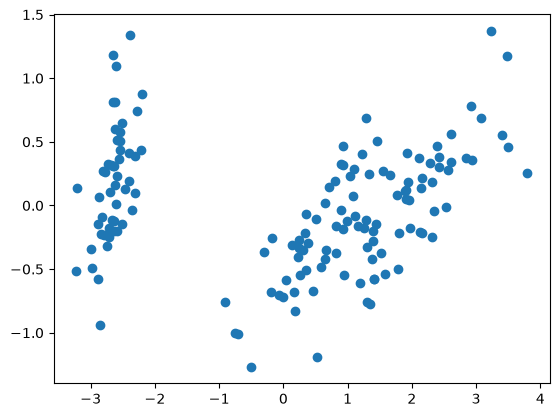

In [109]:
_ = plt.scatter(X[:, 0], X[:, 1])

Fíjate en que, hasta ahora, PCA no ha usado en ningún momento la **especie** de cada flor — es un método *no supervisado*, solo mira las 4 *features* numéricas. Vamos a recuperar la especie real de cada flor (`iris.target`, un número del 0 al 2) únicamente para comprobar, visualmente, si esas 2 componentes que hemos calculado sin conocerla logran separarlas igualmente bien:

In [110]:
iris.target.shape

(150,)

In [111]:
iris.target[0:6]

array([0, 0, 0, 0, 0, 0])

In [113]:
unique_elements, counts_elements = np.unique(iris.target, return_counts=True)
np.asarray((unique_elements, counts_elements))

array([[ 0,  1,  2],
       [50, 50, 50]])

In [114]:
list(iris.target_names)

[np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Coloreando ahora cada punto según su especie real:

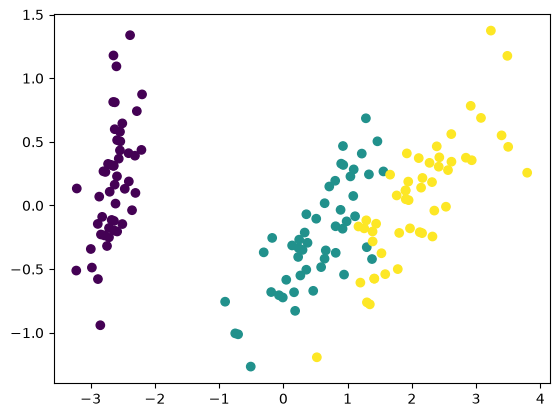

In [115]:
_ = plt.scatter(X[:, 0], X[:, 1], c=iris.target)

A pesar de que PCA nunca vio la etiqueta de especie, las 3 especies aparecen claramente separadas en este espacio de 2 dimensiones — la prueba visual de que las direcciones de máxima varianza que encontró (los vectores propios de la covarianza) también resultan ser, en este caso, muy buenas direcciones para **distinguir** entre grupos, aunque ese no fuera su objetivo explícito.

**Volver a las slides aquí.**

## Aplicaciones de los Valores y Vectores Propios (sólo teoría)

Ya hemos usado la descomposición propia de forma muy concreta: PCA sobre el dataset Iris, reduciendo 4 *features* a 2 componentes principales. Para cerrar el tema, aquí tienes otros sitios (reales, fuera del Machine Learning tradicional incluso) donde exactamente el mismo par $Av=\lambda v$ es la pieza clave — sin código esta vez, solo para que reconozcas el patrón cuando te lo encuentres.

### Eigenfaces: Reconocimiento Facial

**Dónde**: uno de los primeros sistemas prácticos de reconocimiento facial automático (Turk y Pentland, 1991), y todavía una referencia clásica para entender cómo funciona el reconocimiento facial «bajo el capó».

**Cómo**: cada imagen de una cara (una matriz de píxeles) se aplana a un único vector de alta dimensión. Aplicando PCA —es decir, la descomposición propia de la matriz de covarianza— sobre un conjunto grande de caras de entrenamiento, se obtienen sus vectores propios. Al reordenarlos de vuelta como imágenes, tienen un aspecto de caras borrosas y fantasmales — de ahí el nombre **eigenfaces**. Cualquier cara nueva puede aproximarse como una combinación lineal de un puñado de estas eigenfaces (unos pocos pesos, en vez de miles de píxeles), y comparar esos pesos —no los píxeles originales— permite reconocer o verificar una identidad de forma mucho más compacta y rápida.

### Cadenas de Markov y Distribución Estacionaria

**Dónde**: modelar sistemas que van cambiando de estado con probabilidades fijas (previsión del tiempo, comportamiento de usuarios en una web, colas de espera, el propio PageRank de Google que ya mencionamos antes en este notebook).

**Cómo**: si $P$ es la matriz de probabilidades de transición entre estados, la distribución a la que el sistema converge tras muchísimos pasos (la *distribución estacionaria*) es, precisamente, el **vector propio** de $P$ asociado al **valor propio 1**. Es la misma idea de «aplicar la matriz una y otra vez» que vimos al hablar de para qué sirve la descomposición propia.

### Análisis de Vibraciones e Ingeniería Estructural

**Dónde**: diseño de edificios, puentes, alas de avión, carrocerías de coche — cualquier estructura que pueda vibrar.

**Cómo**: a partir de las matrices de masa y rigidez de la estructura, sus **valores propios** son las **frecuencias naturales de vibración**, y los **vectores propios** son los **modos de vibración** (la forma concreta en que la estructura se deforma en cada una de esas frecuencias). Es un cálculo crítico en ingeniería: si una fuerza externa (viento, un terremoto, el propio motor) coincide con una frecuencia natural, se produce **resonancia**, que puede llegar a ser destructiva.

### Compresión y Procesamiento de Imágenes

**Dónde**: ya lo viste con código en el Segmento 3 de este notebook (SVD para comprimir imágenes) — se incluye aquí porque es, en el fondo, la misma idea que las eigenfaces.

**Cómo**: quedarse solo con los primeros valores/vectores propios (o singulares) más grandes de una imagen —los que más varianza/información capturan— y descartar el resto es una forma de compresión con pérdida controlada: se reconstruye una versión muy parecida a la original usando muchos menos números.

---

El hilo común en todos estos casos: cuando una matriz representa una transformación, un sistema o una relación que se repite o se acumula, sus valores y vectores propios revelan las **direcciones e intensidades «naturales»** de ese sistema — la información esencial escondida detrás de una matriz llena de números.

## Resumen: Lo Más Importante de Este Notebook

Una chuleta rápida con lo esencial, para repasar sin tener que releer todo el notebook.

### Transformaciones lineales y vectores propios

* Aplicar una matriz $A$ a un vector ($Av$) es una **transformación lineal**: puede rotarlo, reescalarlo y/o reflejarlo.
* **Vector propio** $v$: una dirección especial que $A$ **no rota**, solo reescala. **Valor propio** $\lambda$: el factor por el que lo escala. $$Av=\lambda v$$
* `lambdas, V = np.linalg.eig(A)` — ¡cuidado!: $V$ (mayúscula) son los **vectores** propios, $\lambda$ (minúscula) son los **valores** propios.

### Determinante

* $\det(A)$: un número que mide cuánto escala $A$ el área (2D) o el volumen (nD). Para $2\times2$: $\det(A)=ad-bc$.
* $\det(A)=0 \Leftrightarrow$ $A$ es **singular** (no tiene inversa).
* $\det(A) = \lambda_1 \cdot \lambda_2 \cdots \lambda_n$ — el producto de todos los valores propios.

### Descomposición propia (eigendecomposition)

* $A = V\Lambda V^{-1}$ ($\Lambda$ = valores propios en una diagonal). Si $A$ es **simétrica**, se puede escribir como $A=Q\Lambda Q^T$ (más barato, porque $Q$ sale ortogonal).
* **¿Para qué sirve?** No para «reconstruir $A$» (eso solo confirma que está bien hecha) — sirve porque $\Lambda$ es diagonal y muy barata de operar: potencias de una matriz ($A^n=V\Lambda^nV^{-1}$), analizar estabilidad de un sistema, y es la base matemática de **PCA**.

### SVD y Pseudoinversa

* **SVD** ($A=UDV^T$): como la descomposición propia, pero funciona con **cualquier matriz**, incluso no cuadrada.
* **Pseudoinversa de Moore-Penrose** ($A^+=VD^+U^T$): el equivalente a «la inversa» para matrices que no tienen inversa de verdad (no cuadradas o singulares).
* **Traza** $\text{Tr}(A)=\sum_i A_{i,i}$: la suma de la diagonal.

### PCA y aplicaciones reales

* **PCA**: aplica esta misma descomposición (propia o SVD) a la matriz de covarianza de un dataset para reducir su dimensionalidad — los vectores propios son las direcciones de máxima varianza. Ejemplo real del notebook: en Iris, 2 componentes principales (de 4 *features* originales) capturan ≈97.8% de toda la varianza.
* El mismo patrón ($Av=\lambda v$) aparece en sitios muy distintos: **Eigenfaces** (reconocimiento facial), **PageRank** (buscadores), cadenas de Markov, análisis de vibraciones e ingeniería estructural, y compresión de imágenes.